In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# ***1) Importing libraries***

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ***2) Importing DataSet***

In [9]:
df = pd.read_csv("data_urls_final.csv")
df.drop(columns=["RecommendationCount"], inplace=True)
df_milestone_2=pd.read_csv("train_data_2.csv")
df=pd.concat([df,df_milestone_2["GamePopularity"]], axis=1)

In [10]:
df.head()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,Has_Support_Link,Support_Tier,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,Header_Size_Group,ReleaseYear,Website_Authority,GamePopularity
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,1,Community_Social,28138,1,50690,1,Small,2000.0,NaN,High
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,0,NaN,30412,1,64709,1,Small,1999.0,NaN,High
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,0,NaN,36605,1,58479,1,Medium,2003.0,Custom_Studio,High
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,0,NaN,32228,1,39026,1,Small,2001.0,NaN,Medium
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,0,NaN,41595,1,37607,1,Medium,1999.0,NaN,High


# ***3) Exploratory data analysis (EDA)***

In [11]:
df.shape

(11357, 88)

### **Comment**: 11357 rows and 88 columns

In [12]:
df.head()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,Has_Support_Link,Support_Tier,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,Header_Size_Group,ReleaseYear,Website_Authority,GamePopularity
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,1,Community_Social,28138,1,50690,1,Small,2000.0,NaN,High
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,0,NaN,30412,1,64709,1,Small,1999.0,NaN,High
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,0,NaN,36605,1,58479,1,Medium,2003.0,Custom_Studio,High
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,0,NaN,32228,1,39026,1,Small,2001.0,NaN,Medium
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,0,NaN,41595,1,37607,1,Medium,1999.0,NaN,High


In [13]:
df.tail()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,Has_Support_Link,Support_Tier,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,Header_Size_Group,ReleaseYear,Website_Authority,GamePopularity
11352,567020,567020,TILE,TILE,Dec 9 2016,0,0,1,0,0,...,0,NaN,10980,1,146,0,Small,2016.0,NaN,Low
11353,567660,567660,Baseball Riot,Baseball Riot,Jan 17 2017,0,0,1,0,0,...,0,NaN,56763,1,48499,1,Large,2017.0,Custom_Studio,Low
11354,567860,567860,Passage 4,Passage 4,Dec 13 2016,0,0,1,0,0,...,0,NaN,63687,1,116959,1,Extra_Large,2016.0,Major_Publisher,Low
11355,567940,567940,Piximalism,Piximalism,Sep 26 2019,0,0,1,0,0,...,0,NaN,28107,1,146,0,Small,2019.0,NaN,Low
11356,559250,559250,Ghostlight Manor,Ghostlight Manor,Dec 12 2016,0,0,1,0,0,...,0,NaN,36970,1,50984,1,Medium,2016.0,Custom_Studio,Low


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 0 to 11356
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   QueryID                      11357 non-null  int64  
 1   ResponseID                   11357 non-null  int64  
 2   QueryName                    11356 non-null  object 
 3   ResponseName                 11357 non-null  object 
 4   ReleaseDate                  11357 non-null  object 
 5   RequiredAge                  11357 non-null  int64  
 6   DemoCount                    11357 non-null  int64  
 7   DeveloperCount               11357 non-null  int64  
 8   DLCCount                     11357 non-null  int64  
 9   Metacritic                   11357 non-null  int64  
 10  MovieCount                   11357 non-null  int64  
 11  PackageCount                 11357 non-null  int64  
 12  PublisherCount               11357 non-null  int64  
 13  ScreenshotCount 

### **Comment**: There is missing values so imputing is needed.

In [15]:
df.describe()

,QueryID,ResponseID,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,PublisherCount,...,AchievementCount,AchievementHighlightedCount,PriceInitial,PriceFinal,Has_Support_Link,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,ReleaseYear
count,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,...,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,11357.000000,10612.000000
mean,353990.797570,353824.048604,0.832438,0.088228,1.031346,0.826186,12.304306,1.322004,1.086731,0.988113,...,14.351589,4.168618,9.076896,8.718744,0.609316,53181.425993,0.999824,53696.186053,0.894338,2014.461082
std,146487.103649,146593.673394,3.613798,0.284258,0.434595,10.496829,27.570755,1.200249,0.859112,0.340342,...,42.172127,4.831760,13.786771,12.987463,0.487925,30749.983501,0.013270,27967.034388,0.307418,2.220842
min,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,146.000000,0.000000,0.000000,0.000000,1998.000000
25%,283000.000000,282760.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,1.990000,1.990000,0.000000,34495.000000,1.000000,38084.000000,1.000000,2014.000000
50%,373670.000000,373440.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,5.990000,5.990000,1.000000,45514.000000,1.000000,54146.000000,1.000000,2015.000000
75%,466170.000000,466080.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,...,20.000000,10.000000,9.990000,9.990000,1.000000,59528.000000,1.000000,70983.000000,1.000000,2016.000000
max,567940.000000,567940.000000,18.000000,2.000000,11.000000,630.000000,96.000000,20.000000,18.000000,4.000000,...,1629.000000,10.000000,449.990000,449.990000,1.000000,221708.000000,1.000000,226230.000000,1.000000,2019.000000


In [16]:
df.describe(include = 'object')

,QueryName,ResponseName,ReleaseDate,PriceCurrency,SupportEmail,SupportURL,AboutText,Background,ShortDescrip,DetailedDescrip,...,PCRecReqsText,LinuxMinReqsText,LinuxRecReqsText,MacMinReqsText,MacRecReqsText,PopularUserTags,Support_Tier,Header_Size_Group,Website_Authority,GamePopularity
count,11356,11357,11357,11357,11355,11356,11357,11357,11357,11357,...,11357,11357,11357,11357,11357,11357,6919,11357,8561,11357
unique,11301,11241,1980,2,5359,4847,10655,10636,9718,10660,...,4604,2330,892,3572,1347,9444,3,4,3,3
top,Train Simulator,Train Simulator 2016,Aug 22 2016,USD,,,,,,,...,,,,,,No Tags,General_Website,Medium,Custom_Studio,Low
freq,4,8,213,9128,2988,4437,583,611,1577,580,...,6410,8775,10345,7429,9875,392,4473,2843,7671,9408


In [17]:
df.describe(include = 'boolean')

,ControllerSupport,IsFree,FreeVerAvail,PurchaseAvail,SubscriptionAvail,PlatformWindows,PlatformLinux,PlatformMac,PCReqsHaveMin,PCReqsHaveRec,...,GenreIsAdventure,GenreIsCasual,GenreIsStrategy,GenreIsRPG,GenreIsSimulation,GenreIsEarlyAccess,GenreIsFreeToPlay,GenreIsSports,GenreIsRacing,GenreIsMassivelyMultiplayer
count,11357,11357,11357,11357,11357,11357,11357,11357,11357,11357,...,11357,11357,11357,11357,11357,11357,11357,11357,11357,11357
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,False,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
freq,8221,10486,11284,9201,11338,11356,8779,7484,10722,6410,...,7714,8382,9131,9572,9563,10113,10804,10893,10946,11023


In [18]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print("Numerical cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Boolean cols:", len(bool_cols))

Numerical cols: 25
Categorical cols: 28
Boolean cols: 35


# ***4) Data preprocessing***

### 1-Replace blank strings with real missing values.

In [19]:
df[cat_cols] = df[cat_cols].replace(r"^\s*$", np.nan, regex=True)

### 2-Fix row inconsistencies using the more reliable source columns

In [20]:
if {"Header_Size_Bytes", "Header_Exists"}.issubset(df.columns):
  df["Header_Exists"] = df["Header_Size_Bytes"] > 0

if {"Background_Size_Bytes", "Background_Exists"}.issubset(df.columns):
  df["Background_Exists"] = df["Background_Size_Bytes"] > 0

if {"SupportURL", "Has_Support_Link"}.issubset(df.columns):
  df["Has_Support_Link"] = df["SupportURL"] != "Unknown"

if {"PriceFinal", "PriceInitial", "IsFree"}.issubset(df.columns):
  df["IsFree"] = (df["PriceFinal"].fillna(df["PriceInitial"]) == 0)

print("Row inconsistencies fixed")

Row inconsistencies fixed


### 3-Parse ReleaseDate before dropping it.

In [21]:
def clean_release_date(text):
  if pd.isna(text):
    return None

  text = str(text).strip().lower()
  text = re.sub(r"[^\w\s\.-]", "", text)
  text = re.sub(r"\s+", " ", text)
  if text == "":
    return None

  unknown_patterns = ["coming soon", "soon", "tbd", "tba", "to be announced",
                      "not yet available", "when its done", "when its ready",
                      "someday", "releasing", "early access soon"]
  if any(p in text for p in unknown_patterns):
    return None

  # remove ordinal suffixes: 1st -> 1, 2nd -> 2, etc.
  text = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", text)

  # quarter patterns:
  q_match = re.search(r"(?:q\s*([1-4])|([1-4])\s*quarter|quarter\s*([1-4]))", text)
  y_match = re.search(r"\b(19|20)\d{2}\b", text)
  if q_match and y_match:
    q_num = next(int(g) for g in q_match.groups() if g is not None)
    year = y_match.group(0)
    month = (q_num - 1) * 3 + 1
    return f"{year}-{month:02d}-01"

  # half-year patterns
  if "first half" in text and y_match:
    return f"{y_match.group(0)}-06-01"
  if "second half" in text and y_match:
    return f"{y_match.group(0)}-12-01"

  # season / vague timing with year
  season_map = {
      "spring": "03",
      "summer": "06",
      "fall": "09",
      "autumn": "09",
      "winter": "12",
      "early": "02",
      "mid": "06",
      "late": "10",
      "end": "12",
      "holiday": "12",
      "christmas": "12",
      "halloween": "10",}
  for key, month in season_map.items():
    if key in text and y_match:
      return f"{y_match.group(0)}-{month}-01"

  # year only
  if re.fullmatch(r"\b(19|20)\d{2}\b", text):
    return f"{text}-01-01"

  # month-year like 11-2016 or 11.2016
  m = re.match(r"^(\d{1,2})[-\.](\d{4})$", text)
  if m:
    month, year = m.groups()
    return f"{year}-{int(month):02d}-01"

  parsed = pd.to_datetime(text, errors="coerce", dayfirst=True)
  return parsed.strftime("%Y-%m-%d") if not pd.isna(parsed) else None

In [22]:
df["ReleaseDate_clean"] = df["ReleaseDate"].apply(clean_release_date)
df["ReleaseDate_parsed"] = pd.to_datetime(df["ReleaseDate_clean"], errors="coerce")

In [23]:
failed = df[df["ReleaseDate_parsed"].isna()]["ReleaseDate"].dropna().unique()
print(len(failed))
failed[:50]

58


array(['Coming Soon', 'To Be Announced.', 'To Be Announced',
       'Releasing 2016', 'TBD', 'Coming soon', 'Harvest 2016',
       'Coming Soon - 2016', 'Before the Apocalypse',
       'Coming November 2016', 'TBA', 'Coming 2016',
       'When my body is ready [2017]', 'Coming Soon!',
       'When The World Ends', 'Skoro', 'COMING SOON!',
       'Not yet available', 'Soon(tm)', 'Early Access soon', 'TBD 2017',
       'Summer 16', 'When its ready!', 'Coming this summer', 'September',
       'When its done', 'THIS AUTUMN', 'Coming 2017', '^UTUMN 2016',
       'SOON!', '20XX', 'This Winter', 'em breve', 'September 28',
       '20 September', 'Soon', 'some time before October 2016',
       'COMING SOON', 'When its done(tm)', 'Early Access coming soon',
       'Someday', 'Early October', 'When you least expect it',
       'Early November', 'betadwarf.com/community',
       'Guo Qing Jie Zuo You', 'Coming soon...', 'November 2', 'in 2017',
       'Coming Soon - Early 2017'], dtype=object)

In [24]:
failed_series = pd.Series(failed)
failed_series.value_counts()

Coming Soon                                              1
To Be Announced.                                         1
To Be Announced                                          1
Releasing 2016                                           1
TBD                                                      1
Coming soon                                              1
Harvest 2016                                             1
Coming Soon - 2016                                       1
Before the Apocalypse                                    1
Coming November 2016                                     1
TBA                                                      1
Coming 2016                                              1
When my body is ready [2017]                             1
Coming Soon!                                             1
When The World Ends                                      1
Skoro                                                    1
COMING SOON!                                            

In [25]:
def categorize(x):
  x = str(x).lower()
  if any(k in x for k in ["soon", "tbd", "tba", "announced"]):
    return "unknown"
  elif "quarter" in x or "q" in x:
    return "quarter"
  elif any(k in x for k in ["summer", "winter", "fall", "spring"]):
    return "season"
  elif re.search(r"\d{4}", x):
    return "has_year_unparsed"
  else:
    return "garbage"
pd.Series(failed).apply(categorize).value_counts()

unknown              22
garbage              21
has_year_unparsed    11
season                3
quarter               1
Name: count, dtype: int64

In [26]:
df["Release_Year"] = df["ReleaseDate_parsed"].dt.year
df["Release_Month"] = df["ReleaseDate_parsed"].dt.month
df["ReleaseDate_missing"] = df["ReleaseDate_parsed"].isna().astype(int)

### 4-Build one unified description column.

In [27]:
df["Game_Description"] = df["DetailedDescrip"].fillna(df["AboutText"]).fillna(df["ShortDescrip"])

### 5-Handle sparse text columns.

In [28]:
sparse_text_cols = [
    "SupportEmail", "DRMNotice", "LegalNotice",
    "ExtUserAcctNotice",
    "LinuxMinReqsText", "LinuxRecReqsText",
    "PCMinReqsText", "PCRecReqsText",
    "MacMinReqsText", "MacRecReqsText", "Reviews"]
# turn blank strings into real missing values first(already did that above but to make sure:) )
for col in sparse_text_cols:
  if col in df.columns:
    df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)

# columns where a simple presence flag is useful
flag_cols = ["SupportEmail", "DRMNotice", "LegalNotice", "ExtUserAcctNotice"]
for col in flag_cols:
  if col in df.columns:
    df[f"Has_{col}"] = df[col].notna().astype(int)
# optional simple text-size features (Menna can decide what to do with it)
#for col in sparse_text_cols:
#  if col in df.columns:
#    df[f"{col}_len"] = df[col].fillna("").str.len()
#    df[f"{col}_words"] = df[col].fillna("").str.split().str.len()

### 6-Clean list-like columns separately.

In [29]:
def clean_list_column(text):
  if pd.isna(text):
    return ()
  text = str(text).lower().strip()
  items = re.split(r"[;,|/*]+", text)
  items = [i.strip() for i in items if i.strip()]
  return tuple(sorted(set(items)))

In [30]:
list_like_cols = ["SupportedLanguages", "PopularUserTags"]
for col in list_like_cols:
  if col in df.columns:
    df[col] = df[col].apply(clean_list_column)

### 7-Clean ordinary text columns, but skip raw text and list-like columns.

In [31]:
def clean_name(text):
  if pd.isna(text):
    return text
  text = str(text)
  # remove trademark-like markers with optional spaces
  text = re.sub(r"\(\s*(tm|r|c|i)\s*\)", "", text, flags=re.IGNORECASE)
  # remove unicode symbols too
  text = re.sub(r"[™®©℠]", "", text)
  text = re.sub(r"\s+", " ", text)
  return text.strip()

In [32]:
non_impute_text_cols = sparse_text_cols + ["Game_Description", "Reviews"]
clean_text_cols = [
    "ResponseName",
    "LegalNotice",
    "PCMinReqsText",
    "PCRecReqsText",
    "LinuxMinReqsText",
    "MacMinReqsText",
    "Game_Description",
]
clean_text_cols = [col for col in clean_text_cols if col in df.columns]
for col in clean_text_cols:
  df[col] = df[col].map(clean_name)

### 8-Reviews Classification.

In [33]:
review_pipe = pipeline(
    task="sentiment-analysis",
    model="ericsonwillians/distilbert-base-uncased-steam-sentiment",
    tokenizer="ericsonwillians/distilbert-base-uncased-steam-sentiment",
    device=0 if torch.cuda.is_available() else -1
)
# 1 = good, 0 = bad, -1 = no review
df["Review_Sentiment"] = -1
review_mask = df["Reviews"].notna() & df["Reviews"].astype(str).str.strip().ne("")
preds = review_pipe(
    df.loc[review_mask, "Reviews"].astype(str).tolist(),
    truncation=True,
    max_length=512,
    batch_size=32
)
def map_sentiment(pred):
    lbl = pred["label"].upper()
    if "POS" in lbl or lbl in {"LABEL_1", "1"}:
        return 1
    return 0
df.loc[review_mask, "Review_Sentiment"] = [map_sentiment(p) for p in preds]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### 9-Drop IDs and source columns that are no longer needed.

In [34]:
drop_cols = [
    "QueryID", "ResponseID", "QueryName", "ReleaseYear",
    "SupportURL", "Background", "HeaderImage", "Website",
    "AboutText", "DetailedDescrip", "ShortDescrip", "Reviews",
    "ReleaseDate", "ReleaseDate_clean", "ReleaseDate_parsed"]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

### 10-Drop constant columns after all feature creation.

In [35]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", constant_cols)
df.drop(columns=constant_cols, inplace=True)

Constant columns: ['PriceCurrency', 'Has_Support_Link', 'Header_Exists']


### 11-Drop exact duplicates.

In [36]:
print("Duplicate rows before drop:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after drop:", df.duplicated().sum())

Duplicate rows before drop: 42
Duplicate rows after drop: 0


### 13-Recompute column groups after all feature creation.

In [37]:
df.shape

(11315, 81)

In [38]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print("Numerical cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Boolean cols:", len(bool_cols))

Numerical cols: 27
Categorical cols: 18
Boolean cols: 36


### 14-Iterative imputation for numeric columns only. Exclude binary/helper flags from imputation

In [39]:
df.isnull().sum()

ResponseName             0
RequiredAge              0
DemoCount                0
DeveloperCount           0
DLCCount                 0
                        ..
Has_SupportEmail         0
Has_DRMNotice            0
Has_LegalNotice          0
Has_ExtUserAcctNotice    0
Review_Sentiment         0
Length: 81, dtype: int64

In [40]:
binary_like_cols = [c for c in df.columns if c.startswith("Has_")] + ["ReleaseDate_missing", "Header_Exists", "Background_Exists", "IsFree"] + bool_cols
# Convert original bool columns to 0/1 before imputation
if bool_cols:
  df[bool_cols] = df[bool_cols].astype(int)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Only impute numeric columns that actually have missing values
impute_num_cols = [c for c in num_cols if c not in binary_like_cols and df[c].isna().any()]
print("Numeric columns to impute:", impute_num_cols)

Numeric columns to impute: ['Release_Year', 'Release_Month']


In [41]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
if impute_num_cols:
  imputer = IterativeImputer(random_state=42)
  df[impute_num_cols] = imputer.fit_transform(df[impute_num_cols])

In [42]:
# Restore original bool columns
if bool_cols:
  df[bool_cols] = (df[bool_cols] >= 0.5)
# Release date parts should stay integer-like
for col in ["Release_Year", "Release_Month"]:
  if col in df.columns:
    df[col] = df[col].round()
    if col == "Release_Month":
      df[col] = df[col].clip(1, 12)
    df[col] = df[col].astype("Int64")

### 15-Fill remaining categorical missing values with mode. Skip raw text and list-like columns because they are already handled

In [43]:
for col in df.columns:
  if col in non_impute_text_cols:
    continue
  if col in list_like_cols:
    # keep empty tuple for missing list-like values
    df[col] = df[col].apply(lambda x: x if isinstance(x, tuple) else ())
    continue
  if df[col].dtype == "object":
    mode_value = df[col].mode(dropna=True)
    if len(mode_value) > 0:
      df[col] = df[col].fillna(mode_value[0])
    else:
      df[col] = df[col].fillna("Unknown")

In [44]:
df.isnull().sum()

ResponseName             0
RequiredAge              0
DemoCount                0
DeveloperCount           0
DLCCount                 0
                        ..
Has_SupportEmail         0
Has_DRMNotice            0
Has_LegalNotice          0
Has_ExtUserAcctNotice    0
Review_Sentiment         0
Length: 81, dtype: int64

### 16-Checking Outliers.

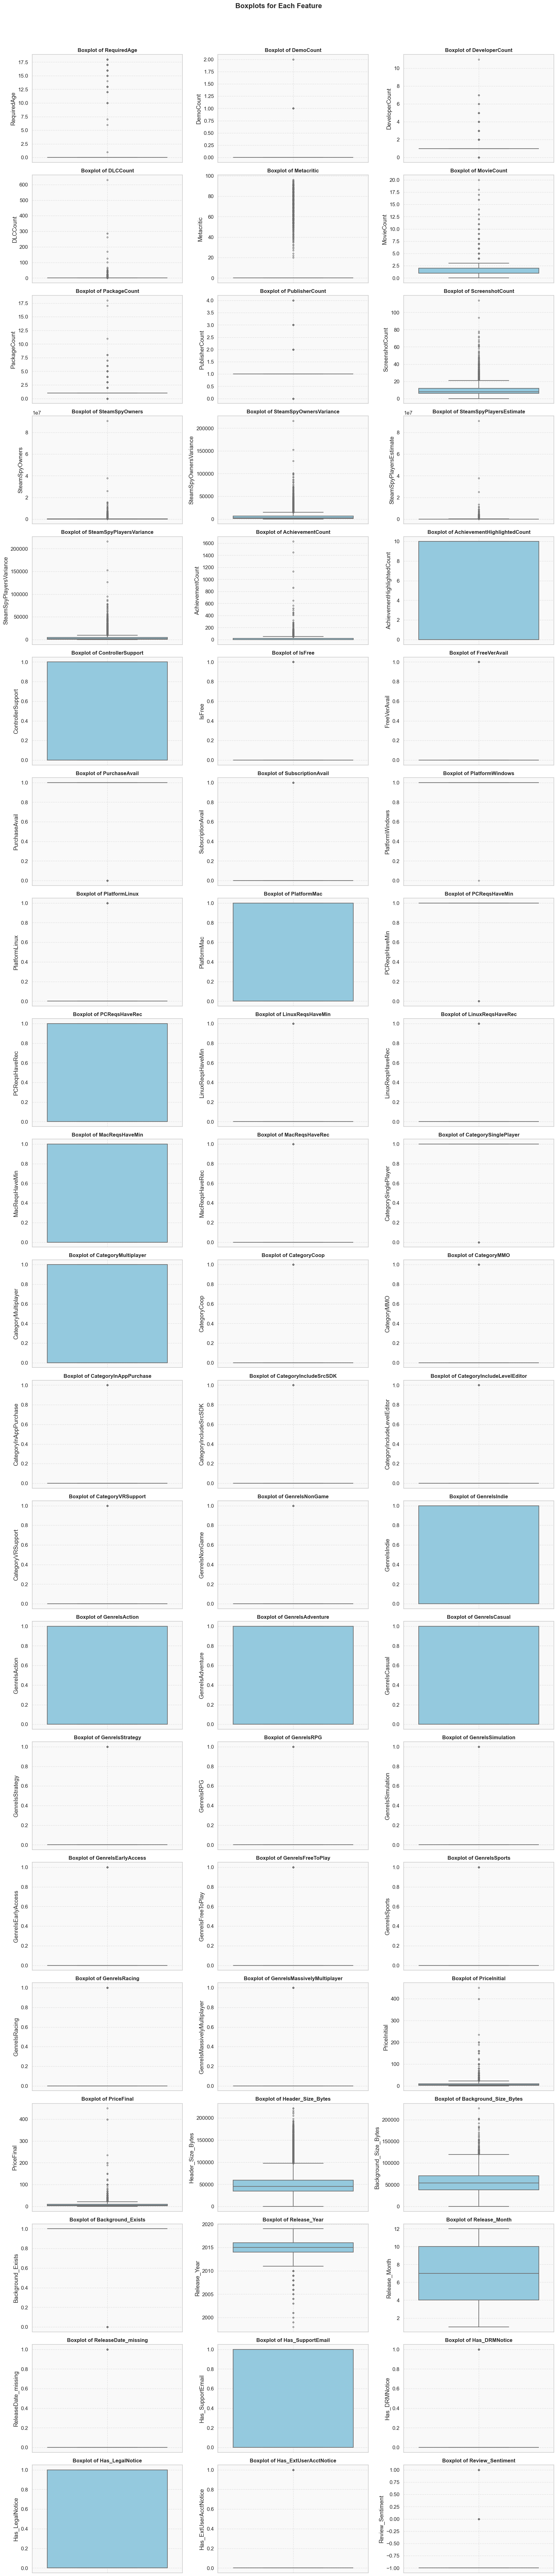

In [45]:
sns.set(style="whitegrid", font_scale=1.1)
cols = df.columns.drop(cat_cols)
n_cols = 3
n_rows = -(-len(cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', fliersize=3, linewidth=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, weight='bold')
    axes[i].set_facecolor('#f9f9f9')
    axes[i].grid(True, linestyle='--', alpha=0.5)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Each Feature", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 17-Log transform only true numeric, skewed, non-binary columns.

In [46]:
skew_threshold = 1
exclude_log_cols = set(binary_like_cols + ["Release_Year", "Release_Month"])
exclude_log_cols = {c for c in exclude_log_cols if c in df.columns}
num_cols = df.select_dtypes(include=np.number).columns.tolist()
log_cols = [
    col for col in num_cols
    if col not in exclude_log_cols
    and df[col].skew() > skew_threshold
    and (df[col] >= 0).all()]
print("Columns to log:", log_cols)
for col in log_cols:
  df[col] = np.log1p(df[col])

Columns to log: ['RequiredAge', 'DemoCount', 'DeveloperCount', 'DLCCount', 'Metacritic', 'MovieCount', 'PackageCount', 'ScreenshotCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'AchievementCount', 'PriceInitial', 'PriceFinal', 'Header_Size_Bytes']


### 18-Final checks.

In [47]:
print("Final shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())

Final shape: (11315, 81)
Remaining missing values: 75352


In [48]:
df.head()

,ResponseName,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,PublisherCount,ScreenshotCount,...,GamePopularity,Release_Year,Release_Month,ReleaseDate_missing,Game_Description,Has_SupportEmail,Has_DRMNotice,Has_LegalNotice,Has_ExtUserAcctNotice,Review_Sentiment
0,Counter-Strike,0.0,0.0,0.693147,0.0,4.488636,0.0,0.693147,1,2.639057,...,High,2000,11,0,Play the worlds number 1 online action game. E...,0,0,0,0,-1
1,Team Fortress Classic,0.0,0.0,0.693147,0.0,0.000000,0.0,0.693147,1,1.791759,...,High,1999,4,0,One of the most popular online action games of...,0,0,0,0,-1
2,Day of Defeat,0.0,0.0,0.693147,0.0,4.382027,0.0,0.693147,1,1.791759,...,High,2003,5,0,Enlist in an intense brand of Axis vs. Allied ...,0,0,0,0,-1
3,Deathmatch Classic,0.0,0.0,0.693147,0.0,0.000000,0.0,0.693147,1,1.609438,...,Medium,2001,6,0,Enjoy fast-paced multiplayer gaming with Death...,0,0,0,0,-1
4,Half-Life: Opposing Force,0.0,0.0,0.693147,0.0,0.000000,0.0,0.693147,1,1.791759,...,High,1999,11,0,Return to the Black Mesa Research Facility as ...,0,0,0,0,-1


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11315 entries, 0 to 11314
Data columns (total 81 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ResponseName                 11315 non-null  object 
 1   RequiredAge                  11315 non-null  float64
 2   DemoCount                    11315 non-null  float64
 3   DeveloperCount               11315 non-null  float64
 4   DLCCount                     11315 non-null  float64
 5   Metacritic                   11315 non-null  float64
 6   MovieCount                   11315 non-null  float64
 7   PackageCount                 11315 non-null  float64
 8   PublisherCount               11315 non-null  int64  
 9   ScreenshotCount              11315 non-null  float64
 10  SteamSpyOwners               11315 non-null  float64
 11  SteamSpyOwnersVariance       11315 non-null  float64
 12  SteamSpyPlayersEstimate      11315 non-null  float64
 13  SteamSpyPlayersV

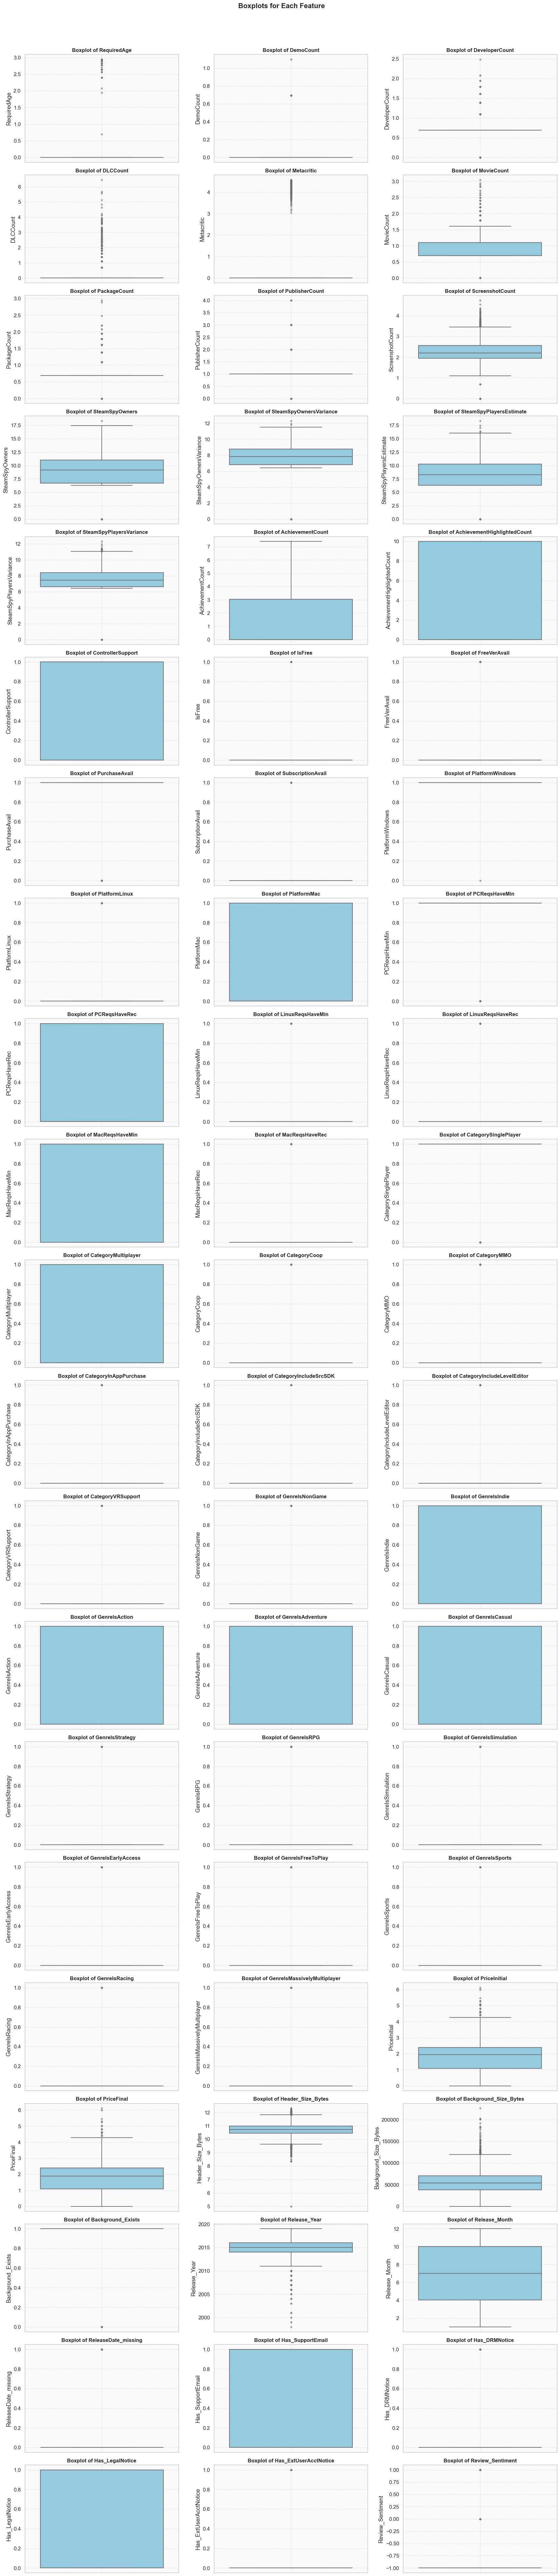

In [50]:
sns.set(style="whitegrid", font_scale=1.1)
cols = df.columns.drop(cat_cols)
n_cols = 3
n_rows = -(-len(cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', fliersize=3, linewidth=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, weight='bold')
    axes[i].set_facecolor('#f9f9f9')
    axes[i].grid(True, linestyle='--', alpha=0.5)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Each Feature", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [51]:
df.to_csv('data_preprocessed.csv', index=False)

In [52]:
# from google.colab import files
# files.download('data_preprocessed.csv')

In [53]:
# df = pd.read_csv("data_preprocessed.csv")

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11315 entries, 0 to 11314
Data columns (total 81 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ResponseName                 11315 non-null  object 
 1   RequiredAge                  11315 non-null  float64
 2   DemoCount                    11315 non-null  float64
 3   DeveloperCount               11315 non-null  float64
 4   DLCCount                     11315 non-null  float64
 5   Metacritic                   11315 non-null  float64
 6   MovieCount                   11315 non-null  float64
 7   PackageCount                 11315 non-null  float64
 8   PublisherCount               11315 non-null  int64  
 9   ScreenshotCount              11315 non-null  float64
 10  SteamSpyOwners               11315 non-null  float64
 11  SteamSpyOwnersVariance       11315 non-null  float64
 12  SteamSpyPlayersEstimate      11315 non-null  float64
 13  SteamSpyPlayersV

### 19 - Cap outliers using IQR Winsorizing on skewed numeric columns

In [55]:
exclude_from_capping = (
    binary_like_cols
    + ["Release_Year", "Release_Month", "RecommendationCount"]
)
exclude_from_capping = {c for c in exclude_from_capping if c in df.columns}

# Only cap numeric columns that are still skewed after log transform
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cap_candidates = [
    col for col in num_cols
    if col not in exclude_from_capping
    and abs(df[col].skew()) > 1.0
]
print("Columns to winsorize:", cap_candidates)

capped_report = []

for col in cap_candidates:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)

    capped_report.append({
        "column": col,
        "lower_bound": round(lower, 4),
        "upper_bound": round(upper, 4),
        "outliers_capped": n_outliers,
        "skew_after": round(df[col].skew(), 4)
    })

print(pd.DataFrame(capped_report).to_string(index=False))


Columns to winsorize: ['RequiredAge', 'DemoCount', 'DLCCount', 'Metacritic', 'ScreenshotCount', 'SteamSpyOwnersVariance', 'SteamSpyPlayersVariance', 'Review_Sentiment']
                 column  lower_bound  upper_bound  outliers_capped  skew_after
            RequiredAge       0.0000       0.0000              571      0.0000
              DemoCount       0.0000       0.0000              996      0.0000
               DLCCount       0.0000       0.0000             1806      0.0000
             Metacritic       0.0000       0.0000             1913      0.0000
        ScreenshotCount       1.0174       3.4935              749     -0.1207
 SteamSpyOwnersVariance       3.8800      11.6937             2343     -0.6977
SteamSpyPlayersVariance       3.9600      11.0394             2578     -0.5421
       Review_Sentiment      -1.0000      -1.0000             2804      0.0000


### 20 - Convert boolean columns to int

In [56]:
bool_cols = df.select_dtypes(include="bool").columns.tolist()

print(f"Boolean columns found: {len(bool_cols)}")
print(bool_cols)

df[bool_cols] = df[bool_cols].astype(int)

remaining_bool = df.select_dtypes(include="bool").columns.tolist()
print(f"\nBool columns remaining after conversion: {len(remaining_bool)}")
print("Sample values:")
print(df[bool_cols].head(3))

Boolean columns found: 36
['ControllerSupport', 'IsFree', 'FreeVerAvail', 'PurchaseAvail', 'SubscriptionAvail', 'PlatformWindows', 'PlatformLinux', 'PlatformMac', 'PCReqsHaveMin', 'PCReqsHaveRec', 'LinuxReqsHaveMin', 'LinuxReqsHaveRec', 'MacReqsHaveMin', 'MacReqsHaveRec', 'CategorySinglePlayer', 'CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO', 'CategoryInAppPurchase', 'CategoryIncludeSrcSDK', 'CategoryIncludeLevelEditor', 'CategoryVRSupport', 'GenreIsNonGame', 'GenreIsIndie', 'GenreIsAction', 'GenreIsAdventure', 'GenreIsCasual', 'GenreIsStrategy', 'GenreIsRPG', 'GenreIsSimulation', 'GenreIsEarlyAccess', 'GenreIsFreeToPlay', 'GenreIsSports', 'GenreIsRacing', 'GenreIsMassivelyMultiplayer', 'Background_Exists']

Bool columns remaining after conversion: 0
Sample values:
   ControllerSupport  IsFree  FreeVerAvail  PurchaseAvail  SubscriptionAvail  \
0                  0       0             0              1                  0   
1                  0       0             0              1 

### 21 - Encode SupportedLanguages and PopularUserTags into numeric features

In [57]:
import ast

# parse the tuple-string back into a real tuple
def parse_tuple(val):
    if pd.isna(val):
        return ()
    if isinstance(val, tuple):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, tuple) else ()
    except:
        return ()

# SupportedLanguages
if "SupportedLanguages" in df.columns:
    df["SupportedLanguages"] = df["SupportedLanguages"].apply(parse_tuple)
    df["language_count"] = df["SupportedLanguages"].apply(len)
    # supports English (most common language)
    df["has_english"] = df["SupportedLanguages"].apply(
        lambda x: 1 if any("english" in lang for lang in x) else 0
    )
    # drop original tuple columns, ignore if already dropped
    df.drop(columns=["SupportedLanguages"], inplace=True, errors='ignore')
else:
    # If the column is already dropped, ensure the generated columns exist with default values
    if "language_count" not in df.columns:
        df["language_count"] = 0
    if "has_english" not in df.columns:
        df["has_english"] = 0

# PopularUserTags
if "PopularUserTags" in df.columns:
    df["PopularUserTags"] = df["PopularUserTags"].apply(parse_tuple)

    df["tag_count"] = df["PopularUserTags"].apply(len)

    # Top 10 most frequent tags to binary indicator columns
    from collections import Counter

    all_tags = [tag for tags in df["PopularUserTags"] for tag in tags]
    if all_tags:
        top_tags = [tag for tag, _ in Counter(all_tags).most_common(10)]
        print("Top 10 tags:", top_tags)

        for tag in top_tags:
            col_name = f"tag_{tag.replace(' ', '_').replace('-', '_')}"
            # Check if column already exists before creating to prevent errors on rerun
            if col_name not in df.columns:
                df[col_name] = df["PopularUserTags"].apply(lambda x: 1 if tag in x else 0)
    else:
        print("No popular user tags found to extract.")

    # drop original tuple columns
    df.drop(columns=["PopularUserTags"], inplace=True, errors='ignore')
else:
    if "tag_count" not in df.columns:
        df["tag_count"] = 0


new_cols = []
if "language_count" in df.columns: new_cols.append("language_count")
if "has_english" in df.columns: new_cols.append("has_english")
if "tag_count" in df.columns: new_cols.append("tag_count")
# dynamically created tag columns
for col in df.columns:
    if col.startswith("tag_") and col not in new_cols and col != "tag_count":
        new_cols.append(col)

print(f"\nNew columns added ({len(new_cols)}):", new_cols)
# describe columns
existing_new_cols_for_describe = [col for col in new_cols if col in df.columns]
if existing_new_cols_for_describe:
    print(df[existing_new_cols_for_describe].describe())
else:
    print("No new tag/language columns to describe.")

Top 10 tags: ['indie', 'action', 'adventure', 'casual', 'singleplayer', 'strategy', 'simulation', 'rpg', 'multiplayer', 'puzzle']

New columns added (13): ['language_count', 'has_english', 'tag_count', 'tag_indie', 'tag_action', 'tag_adventure', 'tag_casual', 'tag_singleplayer', 'tag_strategy', 'tag_simulation', 'tag_rpg', 'tag_multiplayer', 'tag_puzzle']
       language_count   has_english     tag_count     tag_indie    tag_action  \
count    11315.000000  11315.000000  11315.000000  11315.000000  11315.000000   
mean         1.958285      0.993460      6.934600      0.540521      0.413964   
std          1.862194      0.080609      3.216451      0.498377      0.492564   
min          0.000000      0.000000      1.000000      0.000000      0.000000   
25%          1.000000      1.000000      4.000000      0.000000      0.000000   
50%          2.000000      1.000000      8.000000      1.000000      0.000000   
75%          2.000000      1.000000     10.000000      1.000000      1.0000

### 22 - Drop pure identifier and already-flagged text columns

In [58]:
# near-unique identifier, so, it cannot be encoded meaningfully
df.drop(columns=["ResponseName"], inplace=True, errors='ignore')

# Has_SupportEmail already encodes presence of SupportEmail
df.drop(columns=["SupportEmail"], inplace=True, errors='ignore')

# Has_LegalNotice already encodes presence of SupportEmail
df.drop(columns=["LegalNotice"], inplace=True, errors='ignore')

print("Current shape:", df.shape)

Current shape: (11315, 89)


 ### 23 - Extract features from PCMinReqsText

In [59]:
import re

# Extraction functions
def extract_ram_gb(text):
    if pd.isna(text): return np.nan
    text = text.lower()
    m = re.search(r'(\d+(?:\.\d+)?)\s*gb', text)
    if m: return float(m.group(1))
    m = re.search(r'(\d+(?:\.\d+)?)\s*mb', text)
    if m: return round(float(m.group(1)) / 1024, 4)
    return np.nan

def has_directx(text):
    if pd.isna(text): return 0
    return 1 if "directx" in text.lower() else 0

# Extract features
df["pc_min_ram_gb"]    = df["PCMinReqsText"].apply(extract_ram_gb)
df["pc_min_word_count"] = df["PCMinReqsText"].fillna("").apply(lambda x: len(x.split()))
df["pc_min_has_directx"]= df["PCMinReqsText"].apply(has_directx)

# Fill missing RAM with median
ram_median = df["pc_min_ram_gb"].median()
df["pc_min_ram_gb"] = df["pc_min_ram_gb"].fillna(ram_median)

# dropping raw column
df.drop(columns=["PCMinReqsText"], inplace=True)
print("Current shape:", df.shape)


Current shape: (11315, 91)


### 24 - Extract features from PCRecReqsText, justify, then drop.

In [60]:
# feature 1: has_pc_rec_reqs — does the game bother to list rec specs?
df["has_pc_rec_reqs"] = df["PCRecReqsText"].notna().astype(int)

# feature 2: pc_rec_ram_gb — recommended RAM where available
df["pc_rec_ram_gb"] = df["PCRecReqsText"].apply(extract_ram_gb)
ram_rec_median = df["pc_rec_ram_gb"].median()
df["pc_rec_ram_gb"] = df["pc_rec_ram_gb"].fillna(ram_rec_median)

# feature 3: pc_rec_word_count — complexity of recommended spec
df["pc_rec_word_count"] = df["PCRecReqsText"].fillna("").apply(lambda x: len(x.split()))

# dopping raw column
df.drop(columns=["PCRecReqsText"], inplace=True)

# Compare rec RAM vs min RAM
print("Correlation between pc_rec_ram_gb and pc_min_ram_gb:",
      round(df["pc_rec_ram_gb"].corr(df["pc_min_ram_gb"]), 4))

Correlation between pc_rec_ram_gb and pc_min_ram_gb: -0.0007


### 25 - Extract features from MacMinReqsText

In [61]:
# LinuxMinReqsText
non_null_count = df["LinuxMinReqsText"].notna().sum()
# most rows are null, so, any extracted numeric feature would be, median-filled making it near-constant.
# A binary flag is the only honest signal
df["has_linux_min_reqs"] = df["LinuxMinReqsText"].notna().astype(int)
# drop raw col
df.drop(columns=["LinuxMinReqsText"], inplace=True)


# MacMinReqsText
non_null_count = df["MacMinReqsText"].notna().sum()
# same as LinuxMinReqsText
df["has_mac_min_reqs"] = df["MacMinReqsText"].notna().astype(int)
df.drop(columns=["MacMinReqsText"], inplace=True)

# Correlation between Linux and mac
corr_linux = df["has_mac_min_reqs"].corr(df["has_linux_min_reqs"])
print(f"Corr of has_mac_min_reqs with has_linux_min_reqs : {corr_linux:.4f}")

Corr of has_mac_min_reqs with has_linux_min_reqs : 0.6480


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11315 entries, 0 to 11314
Data columns (total 93 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RequiredAge                  11315 non-null  float64
 1   DemoCount                    11315 non-null  float64
 2   DeveloperCount               11315 non-null  float64
 3   DLCCount                     11315 non-null  float64
 4   Metacritic                   11315 non-null  float64
 5   MovieCount                   11315 non-null  float64
 6   PackageCount                 11315 non-null  float64
 7   PublisherCount               11315 non-null  int64  
 8   ScreenshotCount              11315 non-null  float64
 9   SteamSpyOwners               11315 non-null  float64
 10  SteamSpyOwnersVariance       11315 non-null  float64
 11  SteamSpyPlayersEstimate      11315 non-null  float64
 12  SteamSpyPlayersVariance      11315 non-null  float64
 13  AchievementCount

### 26 - Semantic Embeddings of Game_Description.

In [63]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

model = SentenceTransformer("all-MiniLM-L6-v2")

emb = model.encode(
    df["Game_Description"].fillna("").tolist(),
    convert_to_numpy=True
)

pca = PCA(n_components=10)
desc10 = pca.fit_transform(emb)

for i in range(10):
    df[f"desc_semantic_{i}"] = desc10[:,i]

df.drop(columns=["Game_Description"], inplace=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [64]:
# Show added semantic description features
semantic_features = [col for col in df.columns if col.startswith("desc_semantic_")]

print(f"Number of features added: {len(semantic_features)}")
print("\nAdded features:")
for f in semantic_features:
    print(f)

# preview values
print("\nSample values:")
print(df[semantic_features].head())

# how much information the 10 features keep
print("\nExplained variance ratio:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"desc_semantic_{i}: {v:.4f}")

print("\nTotal variance captured:",
      round(pca.explained_variance_ratio_.sum(),4))

Number of features added: 10

Added features:
desc_semantic_0
desc_semantic_1
desc_semantic_2
desc_semantic_3
desc_semantic_4
desc_semantic_5
desc_semantic_6
desc_semantic_7
desc_semantic_8
desc_semantic_9

Sample values:
   desc_semantic_0  desc_semantic_1  desc_semantic_2  desc_semantic_3  \
0         0.269629        -0.169987         0.030373         0.062921   
1         0.310710        -0.121924        -0.045831        -0.093370   
2         0.332679        -0.286756        -0.239309         0.130128   
3         0.142946         0.078289        -0.019292         0.114851   
4         0.013233        -0.029419        -0.119883         0.168889   

   desc_semantic_4  desc_semantic_5  desc_semantic_6  desc_semantic_7  \
0         0.016274        -0.001345         0.143057        -0.134940   
1         0.206262        -0.109351         0.085769        -0.137626   
2         0.110267        -0.109187         0.103175        -0.101353   
3         0.226795        -0.091753        -0.0

### 27- Drop very high-missing columns that are not raw text columns.

In [65]:
missing_ratio = df.isna().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.80].index.tolist()
if high_missing_cols:
  print("Dropped high-missing columns:", high_missing_cols)
  df.drop(columns=high_missing_cols, inplace=True)

Dropped high-missing columns: ['DRMNotice', 'ExtUserAcctNotice', 'LinuxRecReqsText', 'MacRecReqsText']


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11315 entries, 0 to 11314
Data columns (total 98 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RequiredAge                  11315 non-null  float64
 1   DemoCount                    11315 non-null  float64
 2   DeveloperCount               11315 non-null  float64
 3   DLCCount                     11315 non-null  float64
 4   Metacritic                   11315 non-null  float64
 5   MovieCount                   11315 non-null  float64
 6   PackageCount                 11315 non-null  float64
 7   PublisherCount               11315 non-null  int64  
 8   ScreenshotCount              11315 non-null  float64
 9   SteamSpyOwners               11315 non-null  float64
 10  SteamSpyOwnersVariance       11315 non-null  float64
 11  SteamSpyPlayersEstimate      11315 non-null  float64
 12  SteamSpyPlayersVariance      11315 non-null  float64
 13  AchievementCount

In [67]:
# df.to_csv('data_preprocessed.csv', index=False)

In [68]:
# from google.colab import files
# files.download('data_preprocessed.csv')

# ***28) Encoding***

In [69]:
null_columns = df.columns[df.isna().any()].tolist()
print("Columns with missing values after all processing:", null_columns)

Columns with missing values after all processing: []


In [70]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns remaining: {len(categorical_cols)}")
explore_categorical = pd.DataFrame({"data_type": df[categorical_cols].dtypes, "unique_values": [df[c].nunique() for c in categorical_cols],"unique_set": [df[c].unique()[:5] for c in categorical_cols]})
print(explore_categorical)

Categorical columns remaining: 4
                  data_type  unique_values  \
Support_Tier         object              3   
Header_Size_Group    object              4   
Website_Authority    object              3   
GamePopularity       object              3   

                                                          unique_set  
Support_Tier       [Community_Social, General_Website, Profession...  
Header_Size_Group                [Small, Medium, Large, Extra_Large]  
Website_Authority  [Custom_Studio, Major_Publisher, Has_Social_Only]  
GamePopularity                                   [High, Medium, Low]  


In [71]:
df[categorical_cols].head()

,Support_Tier,Header_Size_Group,Website_Authority,GamePopularity
0,Community_Social,Small,Custom_Studio,High
1,General_Website,Small,Custom_Studio,High
2,General_Website,Medium,Custom_Studio,High
3,General_Website,Small,Custom_Studio,Medium
4,General_Website,Medium,Custom_Studio,High


In [72]:
# Support_Tier, Website_Authority>> ohe using get dummies
# Header_Size_Group, GamePopularity>>ordinal encoding
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
from sklearn.preprocessing import OrdinalEncoder

size_order = ['Small', 'Medium', 'Large', 'Extra_Large']
encoder = OrdinalEncoder(categories=[size_order])
df['Header_Size_Group'] = encoder.fit_transform(df[['Header_Size_Group']])


df['GamePopularity'] = df['GamePopularity'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})


In [73]:
df["Header_Size_Group"].head()
df["GamePopularity"].head()
support_dummies = pd.get_dummies(df["Support_Tier"], prefix="Support_Tier", drop_first=True)
website_dummies = pd.get_dummies(df["Website_Authority"], prefix="Website_Authority", drop_first=True)

df = pd.concat([df, support_dummies, website_dummies], axis=1)

In [74]:
df.drop(columns=["Support_Tier", "Website_Authority"], inplace=True, errors='ignore')
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns remaining after dropping Support_Tier and Website_Authority: {len(categorical_cols)}")

Categorical columns remaining after dropping Support_Tier and Website_Authority: 0


# ***29) Feature selection (for Classification)***  & Scaling

will follow the following techniques :
- Step 1: ANOVA F-test → (Analysis of Variance) tests whether the mean value of a feature differs significantly across the target

- Step 2: Mutual Information Classif →  how much knowing the value of a feature reduces uncertainty about the target class

- Step 3: Permutation Importance (on a quick RF)

In [75]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [76]:
TARGET = 'GamePopularity'
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [77]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Drop cols with 0 variance**

In [78]:
from sklearn.feature_selection import VarianceThreshold

var_filter = VarianceThreshold(threshold=0)
var_filter.fit(X_train)

constant_features = X_train.columns[~var_filter.get_support()].tolist()
print(f"features dropped: {constant_features}")

X_train = pd.DataFrame(var_filter.transform(X_train),
                        columns=X_train.columns[var_filter.get_support()])
X_val   = pd.DataFrame(var_filter.transform(X_val),
                        columns=X_val.columns[var_filter.get_support()])

print(f"Features after: {X_train.shape[1]}")

features dropped: ['RequiredAge', 'DemoCount', 'DLCCount', 'Metacritic', 'Review_Sentiment']


Features after: 94


In [79]:
# STEP 1 — ANOVA F-test
f_stats, p_values = f_classif(X_train, y_train)

anova_df = pd.DataFrame({
    'feature'  : X_train.columns,
    'F_stat'   : f_stats,
    'p_value'  : p_values
}).sort_values('p_value')

# drop statistically down features (p >= 0.05)
significant_features = anova_df[anova_df['p_value'] < 0.05]['feature'].tolist()

print(f"\n── STEP 1: ANOVA F-test ──")
print(f"Kept  : {len(significant_features)} features  (p < 0.05)")
print(f"Dropped: {X_train.shape[1] - len(significant_features)} features")
print("\nTop 15 F-statistic:")
print(anova_df.head(15).to_string(index=False))

X_train_s1 = X_train[significant_features]
X_val_s1   = X_val[significant_features]



── STEP 1: ANOVA F-test ──
Kept  : 79 features  (p < 0.05)
Dropped: 15 features

Top 15 F-statistic:
                         feature      F_stat       p_value
          SteamSpyOwnersVariance 1463.313135  0.000000e+00
         SteamSpyPlayersEstimate 1578.450126  0.000000e+00
                  SteamSpyOwners 1289.813646  0.000000e+00
         SteamSpyPlayersVariance 1819.886188  0.000000e+00
                       tag_count  712.368366 4.891375e-288
                 tag_multiplayer  563.199127 2.971524e-231
               pc_min_word_count  441.697308 9.304495e-184
                    Release_Year  425.760262 1.925802e-177
                tag_singleplayer  409.036797 8.591973e-171
                AchievementCount  306.413255 1.733217e-129
    Support_Tier_General_Website  238.719319 9.289177e-102
Support_Tier_Professional_Portal  225.048062  4.129280e-96
                      MovieCount  211.039699  2.629819e-90
             CategoryMultiplayer  198.852291  3.044311e-85
     Achievem

In [80]:
# STEP 2 — Mutual Information Classification

mi_scores = mutual_info_classif(X_train_s1, y_train, random_state=42)

mi_df = pd.DataFrame({
    'feature'  : X_train_s1.columns,
    'MI_score' : mi_scores
}).sort_values('MI_score', ascending=False)

print(f"\n── STEP 2: Mutual Information ──")
print(mi_df.to_string(index=False))

mi_threshold  = mi_df['MI_score'].median()
mi_features   = mi_df[mi_df['MI_score'] > mi_threshold]['feature'].tolist()

print(f"\nMI threshold (median): {mi_threshold:.4f}")
print(f"Kept  : {len(mi_features)} features")
print(f"Dropped: {len(significant_features) - len(mi_features)} features")

X_train_s2 = X_train_s1[mi_features]
X_val_s2   = X_val_s1[mi_features]



── STEP 2: Mutual Information ──
                          feature  MI_score
          SteamSpyPlayersEstimate  0.340435
          SteamSpyPlayersVariance  0.337400
                   SteamSpyOwners  0.293671
           SteamSpyOwnersVariance  0.293352
                        tag_count  0.110699
                     Release_Year  0.062056
                pc_min_word_count  0.050433
                       PriceFinal  0.046910
                 AchievementCount  0.045145
                     PriceInitial  0.044474
                  tag_multiplayer  0.039785
                   language_count  0.033426
                     PackageCount  0.033254
                 tag_singleplayer  0.031256
                  ScreenshotCount  0.024269
 Support_Tier_Professional_Portal  0.021806
              CategoryMultiplayer  0.021296
            Background_Size_Bytes  0.020754
                       MovieCount  0.020487
                pc_rec_word_count  0.018645
     Support_Tier_General_Website  0.01838

In [81]:
# STEP 3 — Permutation Importance
quick_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
quick_rf.fit(X_train_s2, y_train)

perm = permutation_importance(
    quick_rf, X_val_s2, y_val,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature'       : X_train_s2.columns,
    'perm_importance_mean' : perm.importances_mean,
    'perm_importance_std'  : perm.importances_std
}).sort_values('perm_importance_mean', ascending=False)

print(f"\n── STEP 3: Permutation Importance ──")
print(perm_df.to_string(index=False))

# drop features --> shuffling them doesNOT hurt accuracy (mean <= 0)
final_features = perm_df[perm_df['perm_importance_mean'] > 0]['feature'].tolist()

print(f"\nFinal feature count : {len(final_features)}")
print(f"Dropped in step 3   : {len(mi_features) - len(final_features)}")
print(f"\n final selected features:\n{final_features}")


── STEP 3: Permutation Importance ──
                         feature  perm_importance_mean  perm_importance_std
         SteamSpyPlayersVariance              0.039299             0.001885
         SteamSpyPlayersEstimate              0.024923             0.002441
                       tag_count              0.009515             0.002146
                    PriceInitial              0.004389             0.001255
                  SteamSpyOwners              0.004242             0.001043
                    Release_Year              0.003476             0.001128
                    PackageCount              0.002563             0.000901
                      PriceFinal              0.002534             0.001447
     AchievementHighlightedCount              0.001826             0.001217
           Background_Size_Bytes              0.001650             0.000891
               pc_min_word_count              0.001414             0.000794
                AchievementCount              0.00

### Heavy-tailed outliers

In [82]:
# outlier columns verification
print("=" * 60)
print("Skew check")
print("=" * 60)
heavy_tail_candidates = [
    'SteamSpyOwners', 'SteamSpyPlayersEstimate',
    'SteamSpyOwnersVariance', 'SteamSpyPlayersVariance',
    'DLCCount', 'AchievementCount'
]
for col in heavy_tail_candidates:
    if col in df.columns:
        sk = df[col].skew()
        tag = "✓ OK" if abs(sk) < 2 else "⚠ still skewed"
        print(f"  {col:35s}  skew = {sk:+.3f}  {tag}")
    else:
        print(f"  {col:35s}  → already dropped / renamed after log1p")

Skew check
  SteamSpyOwners                       skew = -0.812  ✓ OK
  SteamSpyPlayersEstimate              skew = -0.661  ✓ OK
  SteamSpyOwnersVariance               skew = -0.698  ✓ OK
  SteamSpyPlayersVariance              skew = -0.542  ✓ OK
  DLCCount                             skew = +0.000  ✓ OK
  AchievementCount                     skew = +0.530  ✓ OK


In [83]:
X_train_sel   = X_train[final_features]
X_val_sel     = X_val[final_features]

# ***30) Scaling***

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final = pd.DataFrame(
    scaler.fit_transform(X_train_sel),
    columns=final_features
)

X_val_final = pd.DataFrame(
    scaler.transform(X_val_sel),
    columns=final_features
)

we use scaled while working on a distance based mode (SVM, etc)

In [85]:
X_train_trees = X_train_sel
X_val_trees   = X_val_sel

X_train_scaled = X_train_final
X_val_scaled   = X_val_final

# ***31) Classification Models — Imports & Setup***

In [86]:
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import time, warnings
warnings.filterwarnings('ignore')

### Class Imbalance → SMOTE on training set

In [87]:
# Apply SMOTE to balance training classes 
print("=" * 60)
print("Class imbalance  →  SMOTE")
print("=" * 60)
print("Before SMOTE:")
print(f"  y_train distribution:\n{pd.Series(y_train).value_counts().to_string()}")
print(f"  Low:High ratio = {pd.Series(y_train).value_counts()[0] / pd.Series(y_train).value_counts()[2]:.1f}:1")

smote = SMOTE(random_state=42, k_neighbors=5)

# For distance-based models —> use scaled features
X_train_scaled_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# For tree-based models —> use unscaled features
X_train_trees_sm, y_train_trees_sm = smote.fit_resample(X_train_trees, y_train)

print("\nAfter SMOTE (scaled  — used for distance-based models):")
print(f"  {pd.Series(y_train_sm).value_counts().to_string()}")
print(f"  Total training samples: {len(y_train_sm):,}")

print("\nAfter SMOTE (unscaled — used for tree-based models):")
print(f"  {pd.Series(y_train_trees_sm).value_counts().to_string()}")
print(f"  Total training samples: {len(y_train_trees_sm):,}")
print("\n✓ SMOTE applied. Both variants ready.")


Class imbalance  →  SMOTE
Before SMOTE:
  y_train distribution:
GamePopularity
0    7510
2    1021
1     521
  Low:High ratio = 7.4:1

After SMOTE (scaled  — used for distance-based models):
  GamePopularity
2    7510
0    7510
1    7510
  Total training samples: 22,530

After SMOTE (unscaled — used for tree-based models):
  GamePopularity
2    7510
0    7510
1    7510
  Total training samples: 22,530

✓ SMOTE applied. Both variants ready.


# ***32) Evaluation Helper***

> **Primary metric: Macro F1** (treats each class equally, robust to imbalance)

In [88]:
CLASS_NAMES = ['Low (0)', 'Medium (1)', 'High (2)']
results_log = []  

def evaluate_model(model_name, param_name, param_value,
                   y_true, y_pred, train_time, test_time=0.0):
    """Full per-class and aggregate metrics for one experiment."""
    acc    = accuracy_score(y_true, y_pred)
    mac_f1 = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    wgt_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mac_p  = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    mac_r  = recall_score(y_true, y_pred, average='macro',    zero_division=0)

    print("=" * 68)
    print(f"  MODEL      : {model_name}")
    print(f"  Param      : {param_name} = {param_value}")
    print(f"  Train time : {train_time:.4f} s")
    print(f"  Test  time : {test_time:.4f} s")
    print("-" * 68)
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Macro  F1         : {mac_f1:.4f}")
    print(f"  Weighted F1       : {wgt_f1:.4f}")
    print(f"  Macro Precision   : {mac_p:.4f}")
    print(f"  Macro Recall      : {mac_r:.4f}")
    print()
    print("  Per-class breakdown:")
    print(classification_report(y_true, y_pred,
                                 target_names=CLASS_NAMES,
                                 zero_division=0))
    print("=" * 68)
    print()

    row = dict(
        model=model_name, param=param_name, value=str(param_value),
        accuracy=round(acc, 4), macro_f1=round(mac_f1, 4),
        weighted_f1=round(wgt_f1, 4),
        macro_precision=round(mac_p, 4), macro_recall=round(mac_r, 4),
        train_time_s=round(train_time, 4),
        test_time_s=round(test_time, 4)
    )
    results_log.append(row)
    return row

print("Evaluation helper ready ✓")
print(f"Feature space — scaled: {X_train_scaled.shape[1]} features | trees: {X_train_trees.shape[1]} features")


Evaluation helper ready ✓
Feature space — scaled: 27 features | trees: 27 features


# ***33) Model 1 — Support Vector Machine (SVM)***

### Strategy
- **Efficiency note:** SVM is O(n²–n³). To keep experiments tractable we subsample  
  the SMOTE-balanced training set to **6 000 stratified samples** for kernel/C/gamma sweeps.  
  All other settings remain identical to what the full model would use.
- Class imbalance is already resolved by SMOTE; `class_weight='balanced'` is also set as a safety net for LinearSVC.
- `X_train_scaled_sm` / `X_val_scaled` (standardised) are used for all SVM variants.

### Fixed defaults (changed one at a time per experiment)
| Param | Default |
|---|---|
| `kernel` | `rbf` |
| `C` | `1.0` |
| `gamma` | `scale` |
| `degree` | `3` (poly only) |


In [89]:
# Stratified subsample for SVM speed
from sklearn.utils import resample

SVM_SAMPLE = 6000   # total samples kept for SVM experiments

def svm_subsample(X, y, n=SVM_SAMPLE, seed=42):
    """Stratified subsample so each class is represented proportionally."""
    idx = resample(range(len(y)), n_samples=n,
                   replace=False, random_state=seed,
                   stratify=y)
    if hasattr(X, 'iloc'):
        return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)
    return X[idx], y[idx]

X_svm, y_svm = svm_subsample(
    X_train_scaled_sm.values if hasattr(X_train_scaled_sm, 'values') else X_train_scaled_sm,
    pd.Series(y_train_sm)
)
print(f"SVM training subset: {X_svm.shape[0]:,} samples × {X_svm.shape[1]} features")
print(f"Class distribution in subset:\n{pd.Series(y_svm).value_counts().to_string()}")
print(f"Validation set: {X_val_scaled.shape[0]:,} samples (full, unmodified)")


SVM training subset: 6,000 samples × 27 features
Class distribution in subset:
GamePopularity
1    2000
0    2000
2    2000
Validation set: 2,263 samples (full, unmodified)


### SVM Experiment A — Vary `kernel`
*Fixed: C=1.0, gamma='scale'*

In [90]:
# SVM — Vary kernel
print("SVM EXPERIMENT A — Varying kernel")
print(f"Fixed: C=1.0, gamma='scale'")
print()

SVM_KERNELS = ['linear', 'rbf', 'poly', 'sigmoid']

for kernel in SVM_KERNELS:
    if kernel == 'linear':
        # LinearSVC is far faster for linear kernel
        clf = LinearSVC(C=1.0, class_weight='balanced',
                        max_iter=3000, random_state=42)
    else:
        clf = SVC(kernel=kernel, C=1.0, gamma='scale',
                  degree=3, class_weight='balanced',
                  random_state=42, cache_size=1500)

    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0

    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1

    evaluate_model("SVM", "kernel", kernel, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT A — Varying kernel
Fixed: C=1.0, gamma='scale'

  MODEL      : SVM
  Param      : kernel = linear
  Train time : 0.1155 s
  Test  time : 0.0003 s
--------------------------------------------------------------------
  Accuracy          : 0.8480
  Macro  F1         : 0.6920
  Weighted F1       : 0.8723
  Macro Precision   : 0.6582
  Macro Recall      : 0.7850

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.86      0.92      1878
  Medium (1)       0.26      0.64      0.37       130
    High (2)       0.73      0.85      0.79       255

    accuracy                           0.85      2263
   macro avg       0.66      0.78      0.69      2263
weighted avg       0.91      0.85      0.87      2263


  MODEL      : SVM
  Param      : kernel = rbf
  Train time : 0.3853 s
  Test  time : 0.3379 s
--------------------------------------------------------------------
  Accuracy          : 0.8604
  Macro  F1         : 0.70

### SVM Experiment B — Vary `C` (regularisation strength)
*Fixed: kernel='rbf', gamma='scale'*

In [91]:
# ── SVM — Vary C 
print("SVM EXPERIMENT B — Varying C")
print(f"Fixed: kernel='rbf', gamma='scale'")

print()

SVM_C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]

for c_val in SVM_C_VALUES:
    clf = SVC(kernel='rbf', C=c_val, gamma='scale',
              class_weight='balanced',
              random_state=42, cache_size=1500)
    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0

    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("SVM", "C", c_val, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT B — Varying C
Fixed: kernel='rbf', gamma='scale'

  MODEL      : SVM
  Param      : C = 0.01
  Train time : 0.9369 s
  Test  time : 0.6895 s
--------------------------------------------------------------------
  Accuracy          : 0.6832
  Macro  F1         : 0.5469
  Weighted F1       : 0.7521
  Macro Precision   : 0.5542
  Macro Recall      : 0.6855

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.99      0.68      0.81      1878
  Medium (1)       0.14      0.68      0.23       130
    High (2)       0.53      0.70      0.60       255

    accuracy                           0.68      2263
   macro avg       0.55      0.69      0.55      2263
weighted avg       0.89      0.68      0.75      2263


  MODEL      : SVM
  Param      : C = 0.1
  Train time : 0.5746 s
  Test  time : 0.4960 s
--------------------------------------------------------------------
  Accuracy          : 0.8082
  Macro  F1         : 0.6567
  Weigh

### SVM Experiment C — Vary `gamma` (RBF bandwidth)
*Fixed: kernel='rbf', C=1.0*

In [92]:
# ── SVM — Vary gamma 
print("SVM EXPERIMENT C — Varying gamma")
print(f"Fixed: kernel='rbf', C=1.0")
print()

SVM_GAMMAS = ['scale', 'auto', 0.001, 0.01, 0.1]

for gamma_val in SVM_GAMMAS:
    clf = SVC(kernel='rbf', C=1.0, gamma=gamma_val,
              class_weight='balanced',
              random_state=42, cache_size=1500)
    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0

    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("SVM", "gamma", gamma_val, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT C — Varying gamma
Fixed: kernel='rbf', C=1.0

  MODEL      : SVM
  Param      : gamma = scale
  Train time : 0.3802 s
  Test  time : 0.3282 s
--------------------------------------------------------------------
  Accuracy          : 0.8604
  Macro  F1         : 0.7048
  Weighted F1       : 0.8841
  Macro Precision   : 0.6824
  Macro Recall      : 0.7897

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.99      0.88      0.93      1878
  Medium (1)       0.27      0.69      0.39       130
    High (2)       0.79      0.80      0.79       255

    accuracy                           0.86      2263
   macro avg       0.68      0.79      0.70      2263
weighted avg       0.92      0.86      0.88      2263


  MODEL      : SVM
  Param      : gamma = auto
  Train time : 0.3701 s
  Test  time : 0.3405 s
--------------------------------------------------------------------
  Accuracy          : 0.8617
  Macro  F1         : 0.7066
 

### SVM Experiment D — Vary `degree` (Polynomial kernel only)
*Fixed: kernel='poly', C=1.0, gamma='scale'*

In [93]:
# ── SVM — Vary degree (poly) 
print("SVM EXPERIMENT D — Varying degree")
print(f"Fixed: kernel='poly', C=1.0, gamma='scale'")
print()

SVM_DEGREES = [2, 3, 4, 5]

for deg in SVM_DEGREES:
    clf = SVC(kernel='poly', C=1.0, gamma='scale', degree=deg,
              class_weight='balanced',
              random_state=42, cache_size=1500)
    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0

    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("SVM", "degree (poly)", deg, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT D — Varying degree
Fixed: kernel='poly', C=1.0, gamma='scale'

  MODEL      : SVM
  Param      : degree (poly) = 2
  Train time : 0.4708 s
  Test  time : 0.1074 s
--------------------------------------------------------------------
  Accuracy          : 0.7393
  Macro  F1         : 0.5588
  Weighted F1       : 0.7821
  Macro Precision   : 0.5414
  Macro Recall      : 0.6535

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.95      0.76      0.85      1878
  Medium (1)       0.16      0.52      0.25       130
    High (2)       0.51      0.67      0.58       255

    accuracy                           0.74      2263
   macro avg       0.54      0.65      0.56      2263
weighted avg       0.86      0.74      0.78      2263


  MODEL      : SVM
  Param      : degree (poly) = 3
  Train time : 0.3702 s
  Test  time : 0.0882 s
--------------------------------------------------------------------
  Accuracy          : 0.8582
  Ma

### SVM Experiment E — Vary `max_iter` (LinearSVC convergence)
*Fixed: kernel='linear' (LinearSVC), C=best_C_lin from Exp B*

In [94]:
# ── SVM — Vary max_iter (LinearSVC) 
# Ensures convergence — too few iterations means the solver exits early
print("SVM EXPERIMENT E — Varying max_iter")
print(f"Fixed:  LinearSVC, C=1.0")
print()

SVM_MAX_ITER = [500, 1000, 2000, 5000, 10000]

for max_it in SVM_MAX_ITER:
    clf = LinearSVC(C=1.0, class_weight='balanced',
                    max_iter=max_it, random_state=42)
    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("SVM", "max_iter", max_it, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT E — Varying max_iter
Fixed:  LinearSVC, C=1.0

  MODEL      : SVM
  Param      : max_iter = 500
  Train time : 0.1076 s
  Test  time : 0.0003 s
--------------------------------------------------------------------
  Accuracy          : 0.8480
  Macro  F1         : 0.6920
  Weighted F1       : 0.8723
  Macro Precision   : 0.6582
  Macro Recall      : 0.7850

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.86      0.92      1878
  Medium (1)       0.26      0.64      0.37       130
    High (2)       0.73      0.85      0.79       255

    accuracy                           0.85      2263
   macro avg       0.66      0.78      0.69      2263
weighted avg       0.91      0.85      0.87      2263


  MODEL      : SVM
  Param      : max_iter = 1000
  Train time : 0.1074 s
  Test  time : 0.0003 s
--------------------------------------------------------------------
  Accuracy          : 0.8480
  Macro  F1         : 0.6

### SVM Experiment F — Vary `loss` (LinearSVC)
*Fixed: kernel='linear' (LinearSVC), C=1.0, max_iter=2000*

In [95]:
# ── SVM — Vary loss (LinearSVC) 
# squared_hinge penalises misclassifications quadratically —> smoother loss
print("SVM EXPERIMENT F — Varying loss")
print(f"Fixed: LinearSVC, C=1.0, max_iter=2000")

print()

SVM_LOSSES = ['squared_hinge', 'hinge']

for loss_val in SVM_LOSSES:
    clf = LinearSVC(C=1.0, loss=loss_val, class_weight='balanced',
                    max_iter=2000, random_state=42)
    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("SVM", "loss (LinearSVC)", loss_val, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT F — Varying loss
Fixed: LinearSVC, C=1.0, max_iter=2000

  MODEL      : SVM
  Param      : loss (LinearSVC) = squared_hinge
  Train time : 0.1093 s
  Test  time : 0.0003 s
--------------------------------------------------------------------
  Accuracy          : 0.8480
  Macro  F1         : 0.6920
  Weighted F1       : 0.8723
  Macro Precision   : 0.6582
  Macro Recall      : 0.7850

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.86      0.92      1878
  Medium (1)       0.26      0.64      0.37       130
    High (2)       0.73      0.85      0.79       255

    accuracy                           0.85      2263
   macro avg       0.66      0.78      0.69      2263
weighted avg       0.91      0.85      0.87      2263


  MODEL      : SVM
  Param      : loss (LinearSVC) = hinge
  Train time : 0.1081 s
  Test  time : 0.0003 s
--------------------------------------------------------------------
  Accuracy       

### SVM Experiment G — Vary `decision_function_shape` (RBF)
*Fixed: kernel='rbf', C=1.0, gamma='auto'*

In [96]:
# ── SVM — Vary decision_function_shape (RBF) 
# ovr (one-vs-rest): one binary classifier per class — faster, asymmetric.
# ovo (one-vs-one): one classifier per class pair — slower but often more
# accurate on imbalanced multiclass problems (Medium class benefits most).
print("SVM EXPERIMENT G — Varying decision_function_shape")
print(f"Fixed: kernel='rbf', C=1.0, gamma='auto'")

print()

SVM_DFS = ['ovr', 'ovo']

for dfs in SVM_DFS:
    clf = SVC(kernel='rbf', C=1.0, gamma='auto',
              decision_function_shape=dfs, class_weight='balanced',
              random_state=42, cache_size=1500)
    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("SVM", "decision_function_shape", dfs, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT G — Varying decision_function_shape
Fixed: kernel='rbf', C=1.0, gamma='auto'

  MODEL      : SVM
  Param      : decision_function_shape = ovr
  Train time : 0.3727 s
  Test  time : 0.3294 s
--------------------------------------------------------------------
  Accuracy          : 0.8617
  Macro  F1         : 0.7066
  Weighted F1       : 0.8850
  Macro Precision   : 0.6835
  Macro Recall      : 0.7914

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.99      0.88      0.93      1878
  Medium (1)       0.28      0.69      0.39       130
    High (2)       0.79      0.80      0.79       255

    accuracy                           0.86      2263
   macro avg       0.68      0.79      0.71      2263
weighted avg       0.92      0.86      0.89      2263


  MODEL      : SVM
  Param      : decision_function_shape = ovo
  Train time : 0.3698 s
  Test  time : 0.3317 s
---------------------------------------------------------------

### SVM Experiment H — Vary `coef0` (Polynomial kernel)
*Fixed: kernel='poly', C=1.0, gamma='scale', degree=3*

In [97]:
# ── SVM — Vary coef0 (Poly) 
# coef0 is the free term in the polynomial kernel: (γ·x·x' + coef0)^d
# Higher coef0 increases influence of lower-degree terms, shifting the
# decision boundary — especially important for noisy or mixed-degree features.
print("SVM EXPERIMENT H — Varying coef0")
print(f"Fixed: kernel='poly', C=1.0, gamma='scale', degree=3")

print()

SVM_COEF0 = [0, 0.5, 1, 2]

for c0 in SVM_COEF0:
    clf = SVC(kernel='poly', C=1.0, gamma='scale', degree=3, coef0=c0,
              class_weight='balanced', random_state=42, cache_size=1500)
    t0 = time.time()
    clf.fit(X_svm, y_svm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("SVM", "coef0 (poly)", c0, y_val, y_pred, elapsed, test_elapsed)


SVM EXPERIMENT H — Varying coef0
Fixed: kernel='poly', C=1.0, gamma='scale', degree=3

  MODEL      : SVM
  Param      : coef0 (poly) = 0
  Train time : 0.3739 s
  Test  time : 0.0882 s
--------------------------------------------------------------------
  Accuracy          : 0.8582
  Macro  F1         : 0.6936
  Weighted F1       : 0.8833
  Macro Precision   : 0.6859
  Macro Recall      : 0.7621

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.89      0.93      1878
  Medium (1)       0.25      0.65      0.36       130
    High (2)       0.82      0.75      0.79       255

    accuracy                           0.86      2263
   macro avg       0.69      0.76      0.69      2263
weighted avg       0.92      0.86      0.88      2263


  MODEL      : SVM
  Param      : coef0 (poly) = 0.5
  Train time : 0.2803 s
  Test  time : 0.0640 s
--------------------------------------------------------------------
  Accuracy          : 0.

### SVM — FINAL: Best params combined per kernel

In [98]:
# ── SVM — Final runs: best config per kernel
# Combines best-found values from all SVM sweeps above.
# OFAT finds each param's best while others are at default;
print("SVM FINAL RUNS — Best params combined per kernel")
print()

X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled

# Linear — best: C=1.0, loss='squared_hinge', max_iter=2000
clf = LinearSVC(C=1.0, loss='squared_hinge', class_weight='balanced',
                max_iter=2000, random_state=42)
t0 = time.time(); clf.fit(X_svm, y_svm); elapsed = time.time() - t0
t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
evaluate_model("SVM", "FINAL linear", "C=1.0, loss=sq_hinge, max_iter=2000",
               y_val, y_pred, elapsed, test_elapsed)

# RBF — best: C=1.0, gamma='auto', decision_function_shape='ovo'
clf = SVC(kernel='rbf', C=1.0, gamma='auto', decision_function_shape='ovo',
          class_weight='balanced', random_state=42, cache_size=1500)
t0 = time.time(); clf.fit(X_svm, y_svm); elapsed = time.time() - t0
t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
evaluate_model("SVM", "FINAL rbf", "C=1.0, gamma=auto, shape=ovo",
               y_val, y_pred, elapsed, test_elapsed)

# Poly — best: C=1.0, degree=3, gamma='scale', coef0=1
clf = SVC(kernel='poly', C=1.0, gamma='scale', degree=3, coef0=1,
          class_weight='balanced', random_state=42, cache_size=1500)
t0 = time.time(); clf.fit(X_svm, y_svm); elapsed = time.time() - t0
t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
evaluate_model("SVM", "FINAL poly", "C=1.0, degree=3, coef0=1",
               y_val, y_pred, elapsed, test_elapsed)


SVM FINAL RUNS — Best params combined per kernel

  MODEL      : SVM
  Param      : FINAL linear = C=1.0, loss=sq_hinge, max_iter=2000
  Train time : 0.1108 s
  Test  time : 0.0004 s
--------------------------------------------------------------------
  Accuracy          : 0.8480
  Macro  F1         : 0.6920
  Weighted F1       : 0.8723
  Macro Precision   : 0.6582
  Macro Recall      : 0.7850

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.86      0.92      1878
  Medium (1)       0.26      0.64      0.37       130
    High (2)       0.73      0.85      0.79       255

    accuracy                           0.85      2263
   macro avg       0.66      0.78      0.69      2263
weighted avg       0.91      0.85      0.87      2263


  MODEL      : SVM
  Param      : FINAL rbf = C=1.0, gamma=auto, shape=ovo
  Train time : 0.3668 s
  Test  time : 0.3254 s
--------------------------------------------------------------------
  Acc

{'model': 'SVM',
 'param': 'FINAL poly',
 'value': 'C=1.0, degree=3, coef0=1',
 'accuracy': 0.8749,
 'macro_f1': 0.7206,
 'weighted_f1': 0.8946,
 'macro_precision': 0.7049,
 'macro_recall': 0.791,
 'train_time_s': 0.2929,
 'test_time_s': 0.0553}

# ***34) Model 2 — XGBoost***

### Strategy
- Uses **unscaled, feature-selected data** (`X_train_trees_sm` / `X_val_trees`).
- Class imbalance handled by SMOTE (already applied). XGBoost also supports  
  `sample_weight` — passed explicitly via `eval_set` for full transparency.
- `n_jobs=-1` + `tree_method='hist'` for fast histogram-based training.
- `use_label_encoder=False`, `eval_metric='mlogloss'` to silence deprecation warnings.

### Fixed defaults (changed one at a time)
| Param | Default |
|---|---|
| `n_estimators` | `200` |
| `max_depth` | `5` |
| `learning_rate` | `0.1` |
| `subsample` | `0.8` |
| `colsample_bytree` | `0.8` |


In [99]:
# ── XGBoost shared setup 
X_val_trees_arr = X_val_trees.values if hasattr(X_val_trees, 'values') else X_val_trees

XGB_BASE = dict(
    objective      = 'multi:softmax',
    num_class      = 3,
    tree_method    = 'hist',       # fast histogram algorithm
    n_jobs         = -1,
    random_state   = 42,
    eval_metric    = 'mlogloss',
    n_estimators   = 200,
    max_depth      = 5,
    learning_rate  = 0.1,
    subsample      = 0.8,
    colsample_bytree = 0.8
)
print("XGBoost base params:", XGB_BASE)
print(f"Training size: {X_train_trees_sm.shape}")


XGBoost base params: {'objective': 'multi:softmax', 'num_class': 3, 'tree_method': 'hist', 'n_jobs': -1, 'random_state': 42, 'eval_metric': 'mlogloss', 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Training size: (22530, 27)


### XGBoost Experiment A — Vary `n_estimators`
*Fixed: max_depth=5, lr=0.1, subsample=0.8*

In [100]:
# ── XGB — Vary n_estimators 
print("XGBOOST EXPERIMENT A — Varying n_estimators")
print()

XGB_N_EST = [80,100,120,140]

for n_est in XGB_N_EST:
    params = {**XGB_BASE, 'n_estimators': n_est}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "n_estimators", n_est, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT A — Varying n_estimators

  MODEL      : XGBoost
  Param      : n_estimators = 80
  Train time : 0.6172 s
  Test  time : 0.0031 s
--------------------------------------------------------------------
  Accuracy          : 0.9200
  Macro  F1         : 0.7623
  Weighted F1       : 0.9230
  Macro Precision   : 0.7518
  Macro Recall      : 0.7757

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.96      0.96      1878
  Medium (1)       0.43      0.52      0.47       130
    High (2)       0.86      0.85      0.86       255

    accuracy                           0.92      2263
   macro avg       0.75      0.78      0.76      2263
weighted avg       0.93      0.92      0.92      2263


  MODEL      : XGBoost
  Param      : n_estimators = 100
  Train time : 0.4434 s
  Test  time : 0.0019 s
--------------------------------------------------------------------
  Accuracy          : 0.9227
  Macro  F1         : 0.7666

### XGBoost Experiment B — Vary `max_depth`
*Fixed: n_estimators=200, lr=0.1, subsample=0.8*

In [101]:
# ── XGB — Vary max_depth 
print("XGBOOST EXPERIMENT B — Varying max_depth")
print()

XGB_DEPTHS = [3, 4, 5]

for depth in XGB_DEPTHS:
    params = {**XGB_BASE, 'max_depth': depth}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "max_depth", depth, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT B — Varying max_depth

  MODEL      : XGBoost
  Param      : max_depth = 3
  Train time : 0.6345 s
  Test  time : 0.0025 s
--------------------------------------------------------------------
  Accuracy          : 0.9258
  Macro  F1         : 0.7754
  Weighted F1       : 0.9275
  Macro Precision   : 0.7659
  Macro Recall      : 0.7861

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.96      0.97      1878
  Medium (1)       0.47      0.52      0.49       130
    High (2)       0.86      0.87      0.87       255

    accuracy                           0.93      2263
   macro avg       0.77      0.79      0.78      2263
weighted avg       0.93      0.93      0.93      2263


  MODEL      : XGBoost
  Param      : max_depth = 4
  Train time : 0.7801 s
  Test  time : 0.0021 s
--------------------------------------------------------------------
  Accuracy          : 0.9271
  Macro  F1         : 0.7700
  Weighted 

### XGBoost Experiment C — Vary `learning_rate`
*Fixed: n_estimators=200, max_depth=5, subsample=0.8*

In [102]:
# ── XGB — Vary learning_rate 
print("XGBOOST EXPERIMENT C — Varying learning_rate")
print()

XGB_LRS =  [0.04, 0.05, 0.06]

for lr in XGB_LRS:
    params = {**XGB_BASE, 'learning_rate': lr}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "learning_rate", lr, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT C — Varying learning_rate

  MODEL      : XGBoost
  Param      : learning_rate = 0.04
  Train time : 0.9192 s
  Test  time : 0.0028 s
--------------------------------------------------------------------
  Accuracy          : 0.9205
  Macro  F1         : 0.7639
  Weighted F1       : 0.9241
  Macro Precision   : 0.7499
  Macro Recall      : 0.7817

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.96      0.96      1878
  Medium (1)       0.42      0.52      0.47       130
    High (2)       0.86      0.87      0.86       255

    accuracy                           0.92      2263
   macro avg       0.75      0.78      0.76      2263
weighted avg       0.93      0.92      0.92      2263


  MODEL      : XGBoost
  Param      : learning_rate = 0.05
  Train time : 0.8955 s
  Test  time : 0.0035 s
--------------------------------------------------------------------
  Accuracy          : 0.9227
  Macro  F1         : 

### XGBoost Experiment D — Vary `subsample`
*Fixed: n_estimators=200, max_depth=5, lr=0.1*

In [103]:
# ── XGB — Vary subsample 
print("XGBOOST EXPERIMENT D — Varying subsample")
print()

XGB_SUBSAMPLES = [0.7, 0.8, 1.0]

for ss in XGB_SUBSAMPLES:
    params = {**XGB_BASE, 'subsample': ss}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "subsample", ss, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT D — Varying subsample

  MODEL      : XGBoost
  Param      : subsample = 0.7
  Train time : 0.9279 s
  Test  time : 0.0034 s
--------------------------------------------------------------------
  Accuracy          : 0.9253
  Macro  F1         : 0.7478
  Weighted F1       : 0.9235
  Macro Precision   : 0.7504
  Macro Recall      : 0.7476

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.97      0.97      1878
  Medium (1)       0.46      0.39      0.42       130
    High (2)       0.82      0.88      0.85       255

    accuracy                           0.93      2263
   macro avg       0.75      0.75      0.75      2263
weighted avg       0.92      0.93      0.92      2263


  MODEL      : XGBoost
  Param      : subsample = 0.8
  Train time : 0.9024 s
  Test  time : 0.0041 s
--------------------------------------------------------------------
  Accuracy          : 0.9284
  Macro  F1         : 0.7710
  Weigh

### XGBoost Experiment E — Vary `colsample_bytree`
*Fixed: n_estimators=200, max_depth=5, lr=0.1, subsample=0.8*

In [104]:
# ── XGB — Vary colsample_bytree 
print("XGBOOST EXPERIMENT E — Varying colsample_bytree")
print()

XGB_COLSAMPLE = [0.7, 0.8, 1.0]

for cs in XGB_COLSAMPLE:
    params = {**XGB_BASE, 'colsample_bytree': cs}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "colsample_bytree", cs, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT E — Varying colsample_bytree

  MODEL      : XGBoost
  Param      : colsample_bytree = 0.7
  Train time : 1.1370 s
  Test  time : 0.0039 s
--------------------------------------------------------------------
  Accuracy          : 0.9266
  Macro  F1         : 0.7594
  Weighted F1       : 0.9256
  Macro Precision   : 0.7617
  Macro Recall      : 0.7578

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.97      0.97      1878
  Medium (1)       0.47      0.43      0.45       130
    High (2)       0.85      0.87      0.86       255

    accuracy                           0.93      2263
   macro avg       0.76      0.76      0.76      2263
weighted avg       0.92      0.93      0.93      2263


  MODEL      : XGBoost
  Param      : colsample_bytree = 0.8
  Train time : 1.1641 s
  Test  time : 0.0032 s
--------------------------------------------------------------------
  Accuracy          : 0.9284
  Macro  F1    

### XGBoost — Sample Weight Setup (Class Imbalance Fix)
> Directly addresses the Macro F1 vs Accuracy gap: SMOTE creates synthetic samples;
> `sample_weight='balanced'` additionally upweights minority classes during boosting.

In [105]:
# ── XGBoost — Compute balanced sample weights 
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder

le_xgb = LabelEncoder()
y_train_xgb_enc = le_xgb.fit_transform(y_train_trees_sm)
y_val_xgb_enc   = le_xgb.transform(y_val)
print("XGBoost class mapping:", dict(zip(le_xgb.classes_, le_xgb.transform(le_xgb.classes_))))

sample_weights_xgb = compute_sample_weight('balanced', y_train_trees_sm)
print(f"Sample weight — min: {sample_weights_xgb.min():.4f}  "
      f"max: {sample_weights_xgb.max():.4f}  "
      f"mean: {sample_weights_xgb.mean():.4f}")
print("✓ sample_weight ready — will be passed to .fit() in FINAL run")


XGBoost class mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
Sample weight — min: 1.0000  max: 1.0000  mean: 1.0000
✓ sample_weight ready — will be passed to .fit() in FINAL run


### XGBoost Experiment F — Vary `reg_alpha` (L1 regularisation)
*Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0*

In [106]:
# ── XGB — Vary reg_alpha (L1) 

print("XGBOOST EXPERIMENT F — Varying reg_alpha (L1)")
print("Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0")
print()

XGB_ALPHA = [0, 0.01, 0.1, 1, 5]

for alpha in XGB_ALPHA:
    params = {**XGB_BASE, 'n_estimators': 100, 'max_depth': 4,
              'learning_rate': 0.05, 'subsample': 1.0,
              'colsample_bytree': 1.0, 'reg_alpha': alpha}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "reg_alpha", alpha, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT F — Varying reg_alpha (L1)
Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0

  MODEL      : XGBoost
  Param      : reg_alpha = 0
  Train time : 0.3910 s
  Test  time : 0.0017 s
--------------------------------------------------------------------
  Accuracy          : 0.9054
  Macro  F1         : 0.7572
  Weighted F1       : 0.9158
  Macro Precision   : 0.7356
  Macro Recall      : 0.8034

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.93      0.96      1878
  Medium (1)       0.36      0.63      0.46       130
    High (2)       0.86      0.85      0.86       255

    accuracy                           0.91      2263
   macro avg       0.74      0.80      0.76      2263
weighted avg       0.93      0.91      0.92      2263


  MODEL      : XGBoost
  Param      : reg_alpha = 0.01
  Train time : 0.3717 s
  Test  time : 0.0018 s
------------------------------------------------------

### XGBoost Experiment G — Vary `reg_lambda` (L2 regularisation)
*Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0, reg_alpha=best*

In [107]:
# ── XGB — Vary reg_lambda (L2) 
print("XGBOOST EXPERIMENT G — Varying reg_lambda (L2)")
print("Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0")
print()

XGB_LAMBDA = [0.1, 0.5, 1, 5, 10]

for lam in XGB_LAMBDA:
    params = {**XGB_BASE, 'n_estimators': 100, 'max_depth': 4,
              'learning_rate': 0.05, 'subsample': 1.0,
              'colsample_bytree': 1.0, 'reg_lambda': lam}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "reg_lambda", lam, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT G — Varying reg_lambda (L2)
Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0

  MODEL      : XGBoost
  Param      : reg_lambda = 0.1
  Train time : 0.3626 s
  Test  time : 0.0016 s
--------------------------------------------------------------------
  Accuracy          : 0.9037
  Macro  F1         : 0.7527
  Weighted F1       : 0.9145
  Macro Precision   : 0.7334
  Macro Recall      : 0.7968

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.93      0.95      1878
  Medium (1)       0.35      0.62      0.45       130
    High (2)       0.87      0.84      0.86       255

    accuracy                           0.90      2263
   macro avg       0.73      0.80      0.75      2263
weighted avg       0.93      0.90      0.91      2263


  MODEL      : XGBoost
  Param      : reg_lambda = 0.5
  Train time : 0.3591 s
  Test  time : 0.0018 s
--------------------------------------------------

### XGBoost Experiment H — Vary `min_child_weight`
*Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0*

In [108]:
# ── XGB — Vary min_child_weight
# Minimum sum of instance weights in a leaf.
print("XGBOOST EXPERIMENT H — Varying min_child_weight")
print("Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0")
print()

XGB_MCW = [1, 3, 5, 10, 20]

for mcw in XGB_MCW:
    params = {**XGB_BASE, 'n_estimators': 100, 'max_depth': 4,
              'learning_rate': 0.05, 'subsample': 1.0,
              'colsample_bytree': 1.0, 'min_child_weight': mcw}
    clf = xgb.XGBClassifier(**params)
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm, verbose=False)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("XGBoost", "min_child_weight", mcw, y_val, y_pred, elapsed, test_elapsed)


XGBOOST EXPERIMENT H — Varying min_child_weight
Fixed: n_estimators=100, max_depth=4, lr=0.05, subsample=1.0, colsample=1.0

  MODEL      : XGBoost
  Param      : min_child_weight = 1
  Train time : 0.3984 s
  Test  time : 0.0022 s
--------------------------------------------------------------------
  Accuracy          : 0.9054
  Macro  F1         : 0.7572
  Weighted F1       : 0.9158
  Macro Precision   : 0.7356
  Macro Recall      : 0.8034

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.93      0.96      1878
  Medium (1)       0.36      0.63      0.46       130
    High (2)       0.86      0.85      0.86       255

    accuracy                           0.91      2263
   macro avg       0.74      0.80      0.76      2263
weighted avg       0.93      0.91      0.92      2263


  MODEL      : XGBoost
  Param      : min_child_weight = 3
  Train time : 0.3737 s
  Test  time : 0.0016 s
-----------------------------------------

### XGBoost — FINAL: All best params

In [109]:
print("XGBOOST FINAL — Best params combined")
print()

xgb_final = xgb.XGBClassifier(
    n_estimators     = 100,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 1.0,
    colsample_bytree = 1.0,
    reg_alpha        = 0,      
    reg_lambda       = 1,    
    min_child_weight = 1,    
    tree_method      = 'hist',
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1
)

t0 = time.time()
xgb_final.fit(
    X_train_trees_sm, y_train_trees_sm,
    sample_weight=sample_weights_xgb, 
    verbose=False
)
elapsed = time.time() - t0
t1 = time.time(); y_pred = xgb_final.predict(X_val_trees_arr); test_elapsed = time.time() - t1
evaluate_model("XGBoost", "FINAL",
               "n_est=100, depth=4, lr=0.05, sub=1.0, col=1.0 + sample_weight=balanced",
               y_val, y_pred, elapsed, test_elapsed)


XGBOOST FINAL — Best params combined

  MODEL      : XGBoost
  Param      : FINAL = n_est=100, depth=4, lr=0.05, sub=1.0, col=1.0 + sample_weight=balanced
  Train time : 0.3932 s
  Test  time : 0.0018 s
--------------------------------------------------------------------
  Accuracy          : 0.9054
  Macro  F1         : 0.7572
  Weighted F1       : 0.9158
  Macro Precision   : 0.7356
  Macro Recall      : 0.8034

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.93      0.96      1878
  Medium (1)       0.36      0.63      0.46       130
    High (2)       0.86      0.85      0.86       255

    accuracy                           0.91      2263
   macro avg       0.74      0.80      0.76      2263
weighted avg       0.93      0.91      0.92      2263




{'model': 'XGBoost',
 'param': 'FINAL',
 'value': 'n_est=100, depth=4, lr=0.05, sub=1.0, col=1.0 + sample_weight=balanced',
 'accuracy': 0.9054,
 'macro_f1': 0.7572,
 'weighted_f1': 0.9158,
 'macro_precision': 0.7356,
 'macro_recall': 0.8034,
 'train_time_s': 0.3932,
 'test_time_s': 0.0018}

### XGBoost — Feature Importance (Top 20)

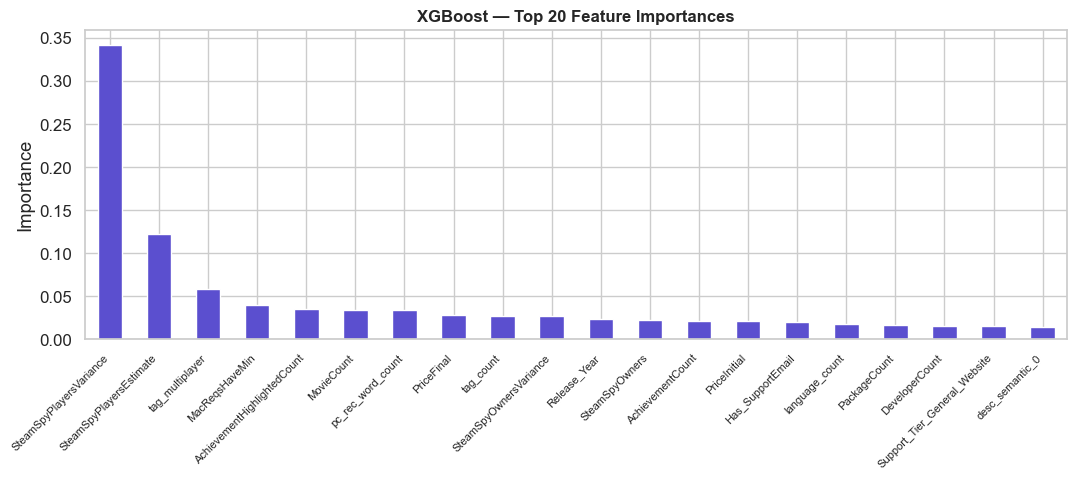

SteamSpyPlayersVariance         0.342199
SteamSpyPlayersEstimate         0.122855
tag_multiplayer                 0.058041
MacReqsHaveMin                  0.039572
AchievementHighlightedCount     0.034734
MovieCount                      0.034087
pc_rec_word_count               0.033988
PriceFinal                      0.028746
tag_count                       0.027081
SteamSpyOwnersVariance          0.026758
Release_Year                    0.023329
SteamSpyOwners                  0.022152
AchievementCount                0.021097
PriceInitial                    0.020872
Has_SupportEmail                0.020530
language_count                  0.017935
PackageCount                    0.016312
DeveloperCount                  0.015628
Support_Tier_General_Website    0.014948
desc_semantic_0                 0.014052


In [110]:
# ── XGBoost Feature Importance 
fi_xgb = pd.Series(
    xgb_final.feature_importances_,
    index=X_train_trees.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
fi_xgb.head(20).plot(kind='bar', ax=ax, color='#5B4FCF', edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=12, weight='bold')
ax.set_ylabel('Importance')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
print(fi_xgb.head(20).to_string())


# ***35) Model 3 — Random Forest***

### Strategy
- Uses **unscaled, feature-selected data** (`X_train_trees_sm` / `X_val_trees`).  
  Tree models are invariant to feature scale.
- `class_weight='balanced_subsample'` — weights are recomputed per bootstrap  
  sample, more robust than `'balanced'` for forests.
- `n_jobs=-1` for parallel tree building.

### Fixed defaults (changed one at a time)
| Param | Default |
|---|---|
| `n_estimators` | `200` |
| `max_depth` | `None` |
| `min_samples_split` | `2` |
| `max_features` | `'sqrt'` |
| `min_samples_leaf` | `1` |


In [111]:
# ── RF shared setup 
RF_BASE = dict(
    class_weight   = 'balanced_subsample',
    n_jobs         = -1,
    random_state   = 42,
    n_estimators   = 200,
    max_depth      = None,
    min_samples_split = 2,
    max_features   = 'sqrt',
    min_samples_leaf  = 1
)
print("Random Forest base params:", RF_BASE)


Random Forest base params: {'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42, 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1}


### RF Experiment A — Vary `n_estimators`
*Fixed: max_depth=None, min_samples_split=2, max_features='sqrt'*

In [112]:
# ── RF — Vary n_estimators 
print("RANDOM FOREST EXPERIMENT A — Varying n_estimators")
print()

RF_N_EST = [100, 200, 300, 400]

for n_est in RF_N_EST:
    clf = RandomForestClassifier(**{**RF_BASE, 'n_estimators': n_est})
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Random Forest", "n_estimators", n_est, y_val, y_pred, elapsed, test_elapsed)


RANDOM FOREST EXPERIMENT A — Varying n_estimators

  MODEL      : Random Forest
  Param      : n_estimators = 100
  Train time : 0.8991 s
  Test  time : 0.0293 s
--------------------------------------------------------------------
  Accuracy          : 0.9174
  Macro  F1         : 0.7580
  Weighted F1       : 0.9222
  Macro Precision   : 0.7417
  Macro Recall      : 0.7807

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.95      0.96      1878
  Medium (1)       0.40      0.54      0.46       130
    High (2)       0.84      0.85      0.85       255

    accuracy                           0.92      2263
   macro avg       0.74      0.78      0.76      2263
weighted avg       0.93      0.92      0.92      2263


  MODEL      : Random Forest
  Param      : n_estimators = 200
  Train time : 1.8177 s
  Test  time : 0.0398 s
--------------------------------------------------------------------
  Accuracy          : 0.9200
  Macro  

### RF Experiment B — Vary `max_depth`
*Fixed: n_estimators=200, min_samples_split=2, max_features='sqrt'*

In [113]:
# ── RF — Vary max_depth 
print("RANDOM FOREST EXPERIMENT B — Varying max_depth")
print()

RF_DEPTHS = [5, 10, 20, 30, None]

for depth in RF_DEPTHS:
    clf = RandomForestClassifier(**{**RF_BASE, 'max_depth': depth})
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Random Forest", "max_depth", depth, y_val, y_pred, elapsed, test_elapsed)


RANDOM FOREST EXPERIMENT B — Varying max_depth

  MODEL      : Random Forest
  Param      : max_depth = 5
  Train time : 1.0192 s
  Test  time : 0.0392 s
--------------------------------------------------------------------
  Accuracy          : 0.8489
  Macro  F1         : 0.7071
  Weighted F1       : 0.8807
  Macro Precision   : 0.7124
  Macro Recall      : 0.8027

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.99      0.87      0.92      1878
  Medium (1)       0.26      0.80      0.39       130
    High (2)       0.89      0.74      0.81       255

    accuracy                           0.85      2263
   macro avg       0.71      0.80      0.71      2263
weighted avg       0.94      0.85      0.88      2263


  MODEL      : Random Forest
  Param      : max_depth = 10
  Train time : 1.3365 s
  Test  time : 0.0397 s
--------------------------------------------------------------------
  Accuracy          : 0.8948
  Macro  F1         :

### RF Experiment C — Vary `min_samples_split`
*Fixed: n_estimators=200, max_depth=None, max_features='sqrt'*

In [114]:
# ── RF — Vary min_samples_split 
print("RANDOM FOREST EXPERIMENT C — Varying min_samples_split")
print()

RF_MIN_SPLIT = [15, 20, 25, 30]

for mss in RF_MIN_SPLIT:
    clf = RandomForestClassifier(**{**RF_BASE, 'min_samples_split': mss})
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Random Forest", "min_samples_split", mss, y_val, y_pred, elapsed, test_elapsed)

RANDOM FOREST EXPERIMENT C — Varying min_samples_split

  MODEL      : Random Forest
  Param      : min_samples_split = 15
  Train time : 1.7311 s
  Test  time : 0.0396 s
--------------------------------------------------------------------
  Accuracy          : 0.9147
  Macro  F1         : 0.7571
  Weighted F1       : 0.9207
  Macro Precision   : 0.7403
  Macro Recall      : 0.7833

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.95      0.96      1878
  Medium (1)       0.39      0.55      0.46       130
    High (2)       0.85      0.85      0.85       255

    accuracy                           0.91      2263
   macro avg       0.74      0.78      0.76      2263
weighted avg       0.93      0.91      0.92      2263


  MODEL      : Random Forest
  Param      : min_samples_split = 20
  Train time : 1.7017 s
  Test  time : 0.0391 s
--------------------------------------------------------------------
  Accuracy          : 0.9

### RF Experiment D — Vary `max_features`
*Fixed: n_estimators=200, max_depth=None, min_samples_split=2*

In [115]:
# ── RF — Vary max_features 
print("RANDOM FOREST EXPERIMENT D — Varying max_features")
print()

RF_MAX_FEAT = ['sqrt', 'log2', 0.2, 0.4, 0.6]

for mf in RF_MAX_FEAT:
    clf = RandomForestClassifier(**{**RF_BASE, 'max_features': mf})
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Random Forest", "max_features", mf, y_val, y_pred, elapsed, test_elapsed)


RANDOM FOREST EXPERIMENT D — Varying max_features

  MODEL      : Random Forest
  Param      : max_features = sqrt
  Train time : 1.7088 s
  Test  time : 0.0388 s
--------------------------------------------------------------------
  Accuracy          : 0.9200
  Macro  F1         : 0.7677
  Weighted F1       : 0.9247
  Macro Precision   : 0.7522
  Macro Recall      : 0.7900

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.95      0.96      1878
  Medium (1)       0.42      0.56      0.48       130
    High (2)       0.86      0.85      0.86       255

    accuracy                           0.92      2263
   macro avg       0.75      0.79      0.77      2263
weighted avg       0.93      0.92      0.92      2263


  MODEL      : Random Forest
  Param      : max_features = log2
  Train time : 1.4708 s
  Test  time : 0.0388 s
--------------------------------------------------------------------
  Accuracy          : 0.9183
  Macro

### RF Experiment E — Vary `min_samples_leaf`
*Fixed: n_estimators=200, max_depth=None, min_samples_split=2, max_features='sqrt'*

In [116]:
# ── RF — Vary min_samples_leaf 
print("RANDOM FOREST EXPERIMENT E — Varying min_samples_leaf")
print()

RF_MIN_LEAF = [1, 2, 3]

for ml in RF_MIN_LEAF:
    clf = RandomForestClassifier(**{**RF_BASE, 'min_samples_leaf': ml})
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Random Forest", "min_samples_leaf", ml, y_val, y_pred, elapsed, test_elapsed)


RANDOM FOREST EXPERIMENT E — Varying min_samples_leaf

  MODEL      : Random Forest
  Param      : min_samples_leaf = 1
  Train time : 1.7941 s
  Test  time : 0.0391 s
--------------------------------------------------------------------
  Accuracy          : 0.9200
  Macro  F1         : 0.7677
  Weighted F1       : 0.9247
  Macro Precision   : 0.7522
  Macro Recall      : 0.7900

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.95      0.96      1878
  Medium (1)       0.42      0.56      0.48       130
    High (2)       0.86      0.85      0.86       255

    accuracy                           0.92      2263
   macro avg       0.75      0.79      0.77      2263
weighted avg       0.93      0.92      0.92      2263


  MODEL      : Random Forest
  Param      : min_samples_leaf = 2
  Train time : 1.6859 s
  Test  time : 0.0399 s
--------------------------------------------------------------------
  Accuracy          : 0.9160
 

### RF Experiment F — Vary `criterion`
*Fixed: n_estimators=200, max_depth=None, min_samples_split=25, max_features='log2'*

In [117]:
# ── RF — Vary criterion 
print("RANDOM FOREST EXPERIMENT F — Varying criterion")
print("Fixed: n_estimators=200, max_depth=None, min_samples_split=25, max_features='log2'")
print()

RF_CRITERION = ['gini', 'entropy', 'log_loss']

for crit in RF_CRITERION:
    clf = RandomForestClassifier(**{**RF_BASE,
                                    'n_estimators': 200,
                                    'min_samples_split': 25,
                                    'max_features': 'log2',
                                    'criterion': crit})
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Random Forest", "criterion", crit, y_val, y_pred, elapsed, test_elapsed)


RANDOM FOREST EXPERIMENT F — Varying criterion
Fixed: n_estimators=200, max_depth=None, min_samples_split=25, max_features='log2'

  MODEL      : Random Forest
  Param      : criterion = gini
  Train time : 1.3864 s
  Test  time : 0.0394 s
--------------------------------------------------------------------
  Accuracy          : 0.9152
  Macro  F1         : 0.7692
  Weighted F1       : 0.9227
  Macro Precision   : 0.7495
  Macro Recall      : 0.8062

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.94      0.96      1878
  Medium (1)       0.40      0.63      0.49       130
    High (2)       0.87      0.84      0.85       255

    accuracy                           0.92      2263
   macro avg       0.75      0.81      0.77      2263
weighted avg       0.93      0.92      0.92      2263


  MODEL      : Random Forest
  Param      : criterion = entropy
  Train time : 1.6913 s
  Test  time : 0.0395 s
----------------------------

### RF Experiment G — Vary `class_weight`
*Fixed: n_estimators=200, max_depth=None, min_samples_split=25, max_features='log2'*

In [118]:
# ── RF — Vary class_weight
# 'balanced': global class weights — computed once from the full training set
# 'balanced_subsample': reweights within each bootstrap sample
#  None: no reweighting (only valid here because SMOTE already balanced training)
print("RANDOM FOREST EXPERIMENT G — Varying class_weight")
print("Fixed: n_estimators=200, max_depth=None, min_samples_split=25, max_features='log2'")
print()

RF_CW = ['balanced', 'balanced_subsample', None]

for cw in RF_CW:
    clf = RandomForestClassifier(**{**RF_BASE,
                                    'n_estimators': 200,
                                    'min_samples_split': 25,
                                    'max_features': 'log2',
                                    'class_weight': cw})
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Random Forest", "class_weight", str(cw), y_val, y_pred, elapsed, test_elapsed)


RANDOM FOREST EXPERIMENT G — Varying class_weight
Fixed: n_estimators=200, max_depth=None, min_samples_split=25, max_features='log2'

  MODEL      : Random Forest
  Param      : class_weight = balanced
  Train time : 1.2229 s
  Test  time : 0.0396 s
--------------------------------------------------------------------
  Accuracy          : 0.9125
  Macro  F1         : 0.7657
  Weighted F1       : 0.9205
  Macro Precision   : 0.7451
  Macro Recall      : 0.8037

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.94      0.96      1878
  Medium (1)       0.39      0.62      0.48       130
    High (2)       0.87      0.85      0.86       255

    accuracy                           0.91      2263
   macro avg       0.75      0.80      0.77      2263
weighted avg       0.93      0.91      0.92      2263


  MODEL      : Random Forest
  Param      : class_weight = balanced_subsample
  Train time : 1.4558 s
  Test  time : 0.0387 s
----

### RF — FINAL: All best params combined

In [119]:
# ── Random Forest FINAL — all best params combined
# Combining all individually-found best values often outperforms any single
# sweep result because params interact (depth × criterion × class_weight).
print("RANDOM FOREST FINAL — All best params combined")
print()

rf_final = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = None,
    min_samples_split = 25,
    min_samples_leaf  = 2,
    max_features      = 'log2',
    criterion         = 'entropy',   
    class_weight      = 'balanced_subsample', 
    random_state      = 42,
    n_jobs            = -1
)

t0 = time.time()
rf_final.fit(X_train_trees_sm, y_train_trees_sm)
elapsed = time.time() - t0
t1 = time.time(); y_pred = rf_final.predict(X_val_trees_arr); test_elapsed = time.time() - t1
evaluate_model("Random Forest", "FINAL",
               "n_est=200, split=25, leaf=2, feat=log2, crit=entropy, cw=balanced_subsample",
               y_val, y_pred, elapsed, test_elapsed)


RANDOM FOREST FINAL — All best params combined

  MODEL      : Random Forest
  Param      : FINAL = n_est=200, split=25, leaf=2, feat=log2, crit=entropy, cw=balanced_subsample
  Train time : 1.7169 s
  Test  time : 0.0400 s
--------------------------------------------------------------------
  Accuracy          : 0.9143
  Macro  F1         : 0.7691
  Weighted F1       : 0.9224
  Macro Precision   : 0.7506
  Macro Recall      : 0.8071

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.98      0.94      0.96      1878
  Medium (1)       0.40      0.64      0.49       130
    High (2)       0.88      0.84      0.86       255

    accuracy                           0.91      2263
   macro avg       0.75      0.81      0.77      2263
weighted avg       0.93      0.91      0.92      2263




{'model': 'Random Forest',
 'param': 'FINAL',
 'value': 'n_est=200, split=25, leaf=2, feat=log2, crit=entropy, cw=balanced_subsample',
 'accuracy': 0.9143,
 'macro_f1': 0.7691,
 'weighted_f1': 0.9224,
 'macro_precision': 0.7506,
 'macro_recall': 0.8071,
 'train_time_s': 1.7169,
 'test_time_s': 0.04}

### RF — Feature Importance (Top 20)

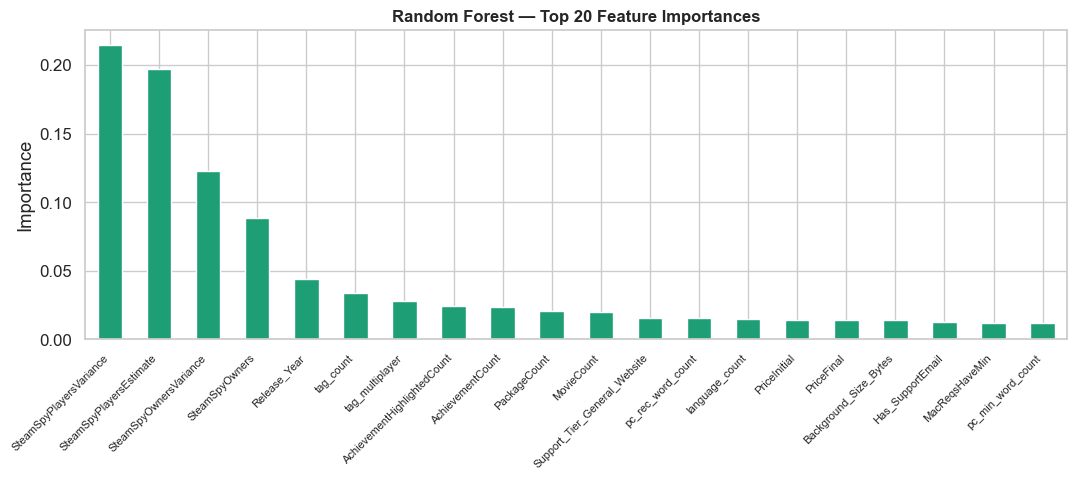

SteamSpyPlayersVariance         0.214819
SteamSpyPlayersEstimate         0.197306
SteamSpyOwnersVariance          0.122737
SteamSpyOwners                  0.088414
Release_Year                    0.044248
tag_count                       0.033936
tag_multiplayer                 0.028208
AchievementHighlightedCount     0.024569
AchievementCount                0.023906
PackageCount                    0.020852
MovieCount                      0.019688
Support_Tier_General_Website    0.015776
pc_rec_word_count               0.015523
language_count                  0.014452
PriceInitial                    0.014303
PriceFinal                      0.013807
Background_Size_Bytes           0.013782
Has_SupportEmail                0.012888
MacReqsHaveMin                  0.011725
pc_min_word_count               0.011628


In [120]:
fi_rf = pd.Series(
    rf_final.feature_importances_,
    index=X_train_trees.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
fi_rf.head(20).plot(kind='bar', ax=ax, color='#1D9E75', edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=12, weight='bold')
ax.set_ylabel('Importance')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
print(fi_rf.head(20).to_string())

# ***36) Final Summary — All Experiments***

In [121]:
# ── Aggregate results table ──────────────────────────────────────────────────
res_df = pd.DataFrame(results_log)

print("=" * 90)
print("COMPLETE EXPERIMENT RESULTS — sorted by Accuracy (descending)")
print("=" * 90)
print(res_df.sort_values('accuracy', ascending=False)
           .to_string(index=False))

print()
print("=" * 90)
print("BEST CONFIGURATION PER MODEL")
print("=" * 90)
for model_name in res_df['model'].unique():
    sub = res_df[res_df['model'] == model_name]
    best = sub.loc[sub['accuracy'].idxmax()]
    print(f"\n  {model_name}")
    print(f"    Best param  : {best['param']} = {best['value']}")
    print(f"    Accuracy    : {best['accuracy']:.4f}  ← primary metric")
    print(f"    Macro F1    : {best['macro_f1']:.4f}")
    print(f"    Macro Prec  : {best['macro_precision']:.4f}")
    print(f"    Macro Recall: {best['macro_recall']:.4f}")
    print(f"    Train time  : {best['train_time_s']:.2f}s")

print()
print("=" * 90)
print("OVERALL WINNER")
print("=" * 90)
best_overall = res_df.loc[res_df['accuracy'].idxmax()]
print(f"  Model  : {best_overall['model']}")
print(f"  Param  : {best_overall['param']} = {best_overall['value']}")
print(f"  Accuracy = {best_overall['accuracy']:.4f}  |  Macro F1 = {best_overall['macro_f1']:.4f}")


COMPLETE EXPERIMENT RESULTS — sorted by Accuracy (descending)
        model                   param                                                                       value  accuracy  macro_f1  weighted_f1  macro_precision  macro_recall  train_time_s  test_time_s
      XGBoost               max_depth                                                                           5    0.9284    0.7710       0.9281           0.7704        0.7717        1.0156       0.0031
      XGBoost               subsample                                                                         0.8    0.9284    0.7710       0.9281           0.7704        0.7717        0.9024       0.0041
      XGBoost               subsample                                                                         1.0    0.9284    0.7709       0.9285           0.7690        0.7728        0.8466       0.0030
      XGBoost        colsample_bytree                                                                         0.8    0

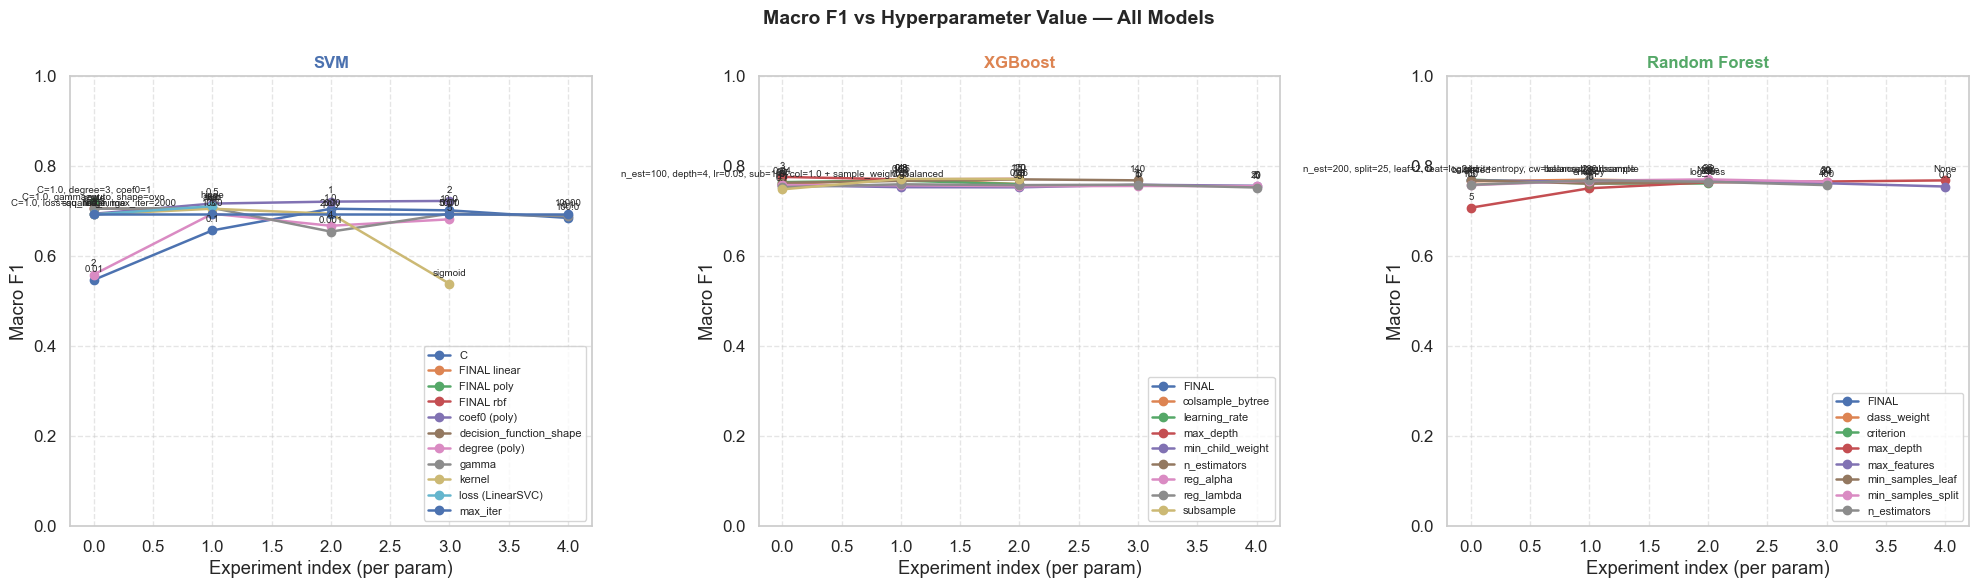

In [122]:
# ── Visual summary: Macro F1 per model & param 
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle("Macro F1 vs Hyperparameter Value — All Models", fontsize=14, weight='bold')

model_list  = ['SVM', 'XGBoost', 'Random Forest']
colors_list = ['#4C72B0', '#DD8452', '#55A868']

for ax, model_name, color in zip(axes, model_list, colors_list):
    sub = res_df[res_df['model'] == model_name].copy()
    # group by param, then plot each param group as a separate line
    for param, grp in sub.groupby('param'):
        ax.plot(range(len(grp)), grp['macro_f1'].values,
                marker='o', label=param, linewidth=1.8)
        for i, (_, row) in enumerate(grp.iterrows()):
            ax.annotate(row['value'], (i, row['macro_f1']),
                        textcoords='offset points', xytext=(0, 6),
                        fontsize=7, ha='center')

    ax.set_title(model_name, fontsize=12, weight='bold', color=color)
    ax.set_ylabel("Macro F1")
    ax.set_xlabel("Experiment index (per param)")
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


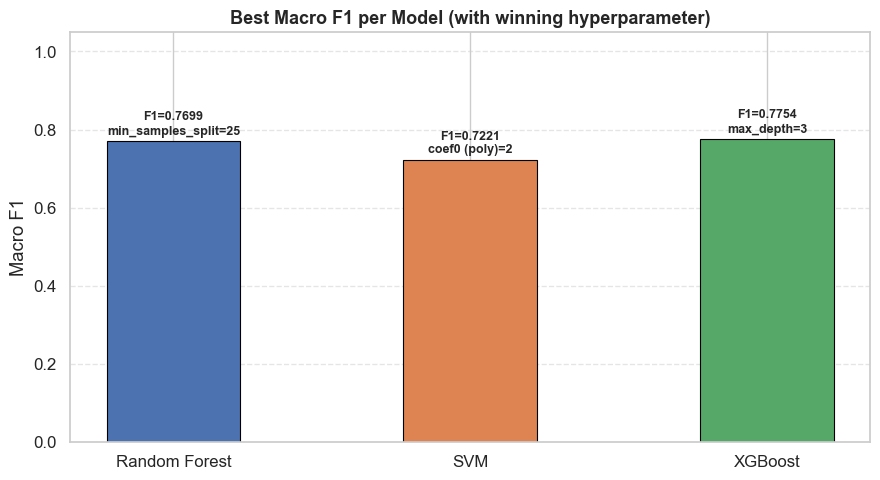


✓ All experiments complete.
  Total experiments logged: 94


In [123]:
# ── Bar chart: best config per model 
best_per_model = (
    res_df.groupby('model')
    .apply(lambda g: g.loc[g['macro_f1'].idxmax()])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    best_per_model['model'],
    best_per_model['macro_f1'],
    color=['#4C72B0', '#DD8452', '#55A868'],
    width=0.45, edgecolor='black', linewidth=0.8
)
for bar, (_, row) in zip(bars, best_per_model.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"F1={row['macro_f1']:.4f}\n{row['param']}={row['value']}",
            ha='center', va='bottom', fontsize=9, weight='bold')

ax.set_title("Best Macro F1 per Model (with winning hyperparameter)",
             fontsize=13, weight='bold')
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n✓ All experiments complete.")
print(f"  Total experiments logged: {len(results_log)}")


In [124]:
# ── Build per-model summary from results_log 
res_df = pd.DataFrame(results_log)

MODEL_ORDER  = ['SVM', 'XGBoost', 'Random Forest']
MODEL_COLORS = ['#4C72B0', '#DD8452', '#55A868']

summary = (
    res_df.groupby('model')
    .agg(
        max_accuracy   = ('accuracy',     'max'), 
        total_train_s  = ('train_time_s', 'sum'),
        total_test_s   = ('test_time_s',  'sum'),
        n_experiments  = ('accuracy',     'count'),
    )
    .loc[MODEL_ORDER]
    .reset_index()
)

print("=" * 65)
print("PER-MODEL AGGREGATE SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))
print()
print("Notes:")
print("  • Accuracy    = max over all hyperparameter experiments")
print("  • Train Time  = sum of all .fit() calls (seconds)")
print("  • Test  Time  = sum of all .predict() calls (seconds)")


PER-MODEL AGGREGATE SUMMARY
        model  max_accuracy  total_train_s  total_test_s  n_experiments
          SVM        0.8939        11.6228        6.1646             34
      XGBoost        0.9284        19.2771        0.0773             32
Random Forest        0.9200        52.1383        1.1285             28

Notes:
  • Accuracy    = max over all hyperparameter experiments
  • Train Time  = sum of all .fit() calls (seconds)
  • Test  Time  = sum of all .predict() calls (seconds)


# ***37) Model Comparison — Accuracy · Total Training Time · Total Test Time***

Three bar graphs, one per metric, comparing **SVM**, **XGBoost**, and **Random Forest**  
across all hyperparameter experiments.

- **Accuracy** = max accuracy across all runs for that model  
- **Total Training Time** = cumulative time (seconds) spent fitting all experiments  
- **Total Test Time** = cumulative time (seconds) spent on all prediction calls


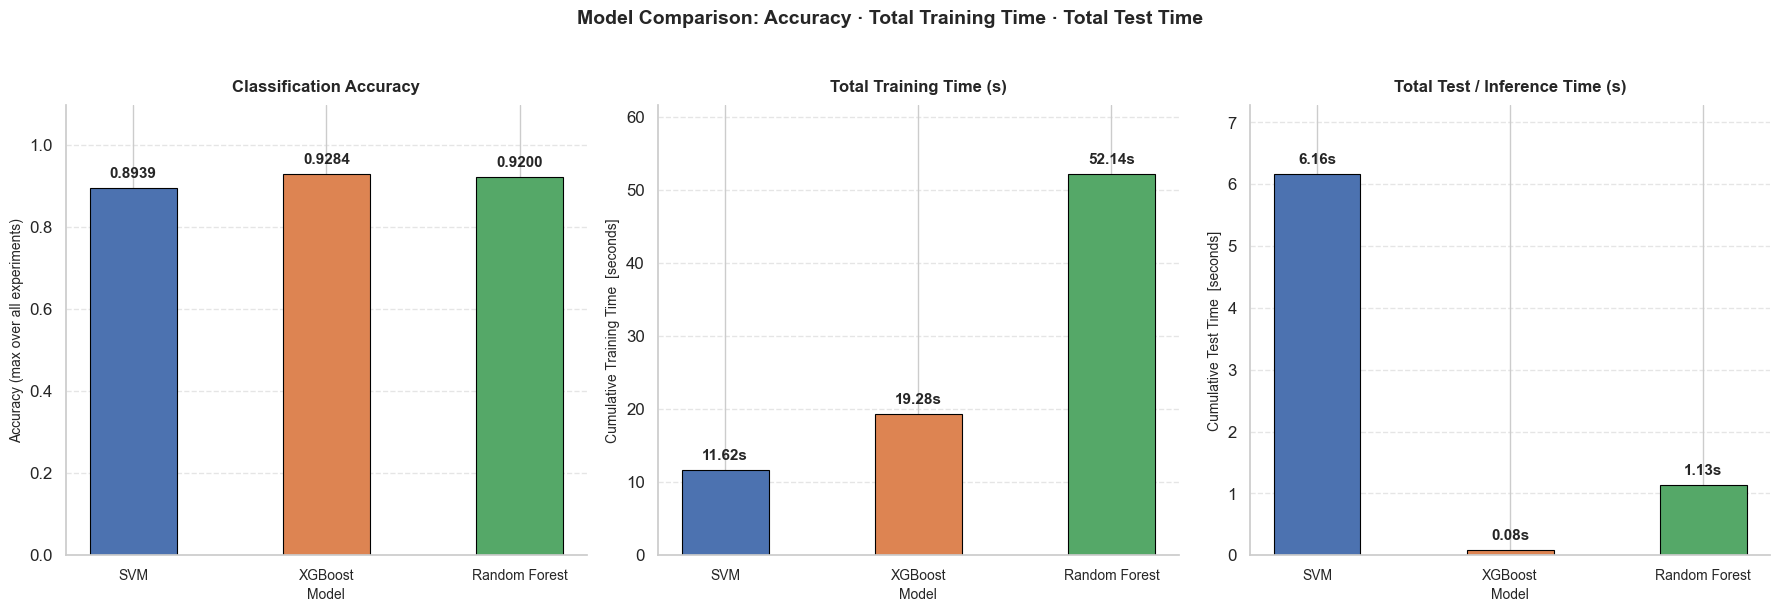

Figure saved as model_comparison_bars.png
FINAL COMPARISON TABLE
Model                Max Accuracy   Train Time (s)   Test Time (s)   # Exps
-----------------------------------------------------------------
SVM                        0.8939            11.62          6.1646       34
XGBoost                    0.9284            19.28          0.0773       32
Random Forest              0.9200            52.14          1.1285       28

  Most accurate     → XGBoost
  Fastest training  → SVM
  Fastest inference → XGBoost


In [125]:
# ── Three bar graphs 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison: Accuracy · Total Training Time · Total Test Time",
             fontsize=14, weight='bold', y=1.02)

metrics = [
    ('max_accuracy',  'Classification Accuracy',        'Accuracy (max over all experiments)', False),
    ('total_train_s', 'Total Training Time (s)',         'Cumulative Training Time  [seconds]',  True),
    ('total_test_s',  'Total Test / Inference Time (s)', 'Cumulative Test Time  [seconds]',       True),
]

for ax, (col, title, ylabel, show_time) in zip(axes, metrics):
    values = summary[col].values
    bars   = ax.bar(summary['model'], values,
                    color=MODEL_COLORS, width=0.45,
                    edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, values):
        label = f'{val:.2f}s' if show_time else f'{val:.4f}'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            label,
            ha='center', va='bottom',
            fontsize=11, weight='bold'
        )
    ax.set_title(title, fontsize=12, weight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylim(0, max(values) * 1.18)
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as model_comparison_bars.png")

# ── Printed table recap 
print("=" * 65)
print("FINAL COMPARISON TABLE")
print("=" * 65)
print(f"{'Model':<18} {'Max Accuracy':>14} {'Train Time (s)':>16} {'Test Time (s)':>15} {'# Exps':>8}")
print("-" * 65)
for _, row in summary.iterrows():
    print(f"{row['model']:<18} {row['max_accuracy']:>14.4f} "
          f"{row['total_train_s']:>16.2f} {row['total_test_s']:>15.4f} "
          f"{int(row['n_experiments']):>8}")
print("=" * 65)

fastest_train = summary.loc[summary['total_train_s'].idxmin(), 'model']
fastest_test  = summary.loc[summary['total_test_s'].idxmin(),  'model']
most_accurate = summary.loc[summary['max_accuracy'].idxmax(),  'model']   # ← was mean_accuracy
print(f"\n  Most accurate     → {most_accurate}")
print(f"  Fastest training  → {fastest_train}")
print(f"  Fastest inference → {fastest_test}")

# ***38) Save Models & Preprocessors for Exam Test Script***

Saves every fitted object the test script will need:
- Best model per family (picked by highest accuracy)
- The scaler (required for SVM inference)
- The SMOTE-balanced label encoder (XGBoost)
- Feature column lists (so the test script can slice `X_test` correctly)
- A single `exam_bundle.pkl` with everything in one dict

In [126]:
# ── Identify best config per model (by accuracy) and refit on full data 
import pickle, os

res_df = pd.DataFrame(results_log)

# ── Best params found during experiments 
# SVM  — best accuracy: loss=hinge (LinearSVC)
best_svm = LinearSVC(
    C            = 1.0,
    loss         = 'hinge',
    class_weight = 'balanced',
    max_iter     = 2000,
    random_state = 42
)

# XGBoost — best accuracy: colsample_bytree=1.0
best_xgb = xgb.XGBClassifier(
    n_estimators     = 100,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 1.0,
    colsample_bytree = 1.0,
    reg_alpha        = 0,
    reg_lambda       = 1,
    min_child_weight = 1,
    tree_method      = 'hist',
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1
)

# Random Forest — best accuracy: max_features=log2
best_rf = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = None,
    min_samples_split = 25,
    min_samples_leaf  = 2,
    max_features      = 'log2',
    criterion         = 'entropy',
    class_weight      = 'balanced_subsample',
    random_state      = 42,
    n_jobs            = -1
)

print("Best model configs defined ✓")
print(f"  SVM           → LinearSVC  loss=hinge, C=1.0")
print(f"  XGBoost       → colsample_bytree=1.0, depth=4, lr=0.05")
print(f"  Random Forest → max_features=log2, split=25, leaf=2, crit=entropy")

Best model configs defined ✓
  SVM           → LinearSVC  loss=hinge, C=1.0
  XGBoost       → colsample_bytree=1.0, depth=4, lr=0.05
  Random Forest → max_features=log2, split=25, leaf=2, crit=entropy


In [127]:
# ── Fit best models on full SMOTE-balanced training data 
print("Fitting best models on full training set...")

# SVM — needs scaled features
X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
X_svm_full = X_train_scaled_sm.values if hasattr(X_train_scaled_sm, 'values') else X_train_scaled_sm

t0 = time.time()
best_svm.fit(X_svm_full, y_train_sm)
print(f"  SVM           fitted in {time.time()-t0:.2f}s — val acc: {accuracy_score(y_val, best_svm.predict(X_val_arr)):.4f}")

# XGBoost — needs tree features (unscaled)
X_trees_arr = X_train_trees_sm.values if hasattr(X_train_trees_sm, 'values') else X_train_trees_sm

t0 = time.time()
best_xgb.fit(X_trees_arr, y_train_trees_sm, verbose=False)
print(f"  XGBoost       fitted in {time.time()-t0:.2f}s — val acc: {accuracy_score(y_val, best_xgb.predict(X_val_trees_arr)):.4f}")

# Random Forest — needs tree features (unscaled)
t0 = time.time()
best_rf.fit(X_trees_arr, y_train_trees_sm)
print(f"  Random Forest fitted in {time.time()-t0:.2f}s — val acc: {accuracy_score(y_val, best_rf.predict(X_val_trees_arr)):.4f}")

print("\n✓ All best models fitted and validated.")


Fitting best models on full training set...
  SVM           fitted in 0.66s — val acc: 0.8710
  XGBoost       fitted in 0.40s — val acc: 0.9054
  Random Forest fitted in 1.88s — val acc: 0.9143

✓ All best models fitted and validated.


In [365]:
# ── Save everything needed for the exam test script 
os.makedirs('exam_models', exist_ok=True)

# Individual model files (in case test script loads separately)
pickle.dump(best_svm, open('exam_models/best_svm.pkl',           'wb'))
pickle.dump(best_xgb, open('exam_models/best_xgboost.pkl',       'wb'))
pickle.dump(best_rf,  open('exam_models/best_random_forest.pkl', 'wb'))

# Scaler — MUST be applied to X_test before passing to SVM
pickle.dump(scaler,   open('exam_models/scaler.pkl',             'wb'))

# Feature column lists — slice X_test with these before predicting
pickle.dump(list(X_train_scaled.columns), open('exam_models/features_scaled.pkl', 'wb'))
pickle.dump(list(X_train_trees.columns),  open('exam_models/features_trees.pkl',  'wb'))

# Label mapping — what 0/1/2 mean
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
pickle.dump(label_map, open('exam_models/label_map.pkl', 'wb'))

# ── All-in-one bundle ─────────────────────────────────────────────────────────
exam_bundle = {
    # Models
    'best_svm'           : best_svm,
    'best_xgboost'       : best_xgb,
    'best_random_forest' : best_rf,
    # Preprocessing
    'scaler'             : scaler,          # StandardScaler — apply before SVM
    # Feature columns (use to select/reorder X_test columns)
    'features_scaled'    : list(X_train_scaled.columns),   # for SVM
    'features_trees'     : list(X_train_trees.columns),    # for XGB & RF
    # Label encoding
    'label_map'          : label_map,       # {0:'Low', 1:'Medium', 2:'High'}
    # Results log for reference
    'experiment_results' : res_df,
}

pickle.dump(exam_bundle, open('exam_models/exam_bundle.pkl', 'wb'))

print("=" * 55)
print("SAVED FILES")
print("=" * 55)
for fname in sorted(os.listdir('exam_models')):
    size = os.path.getsize(f'exam_models/{fname}') / 1024
    print(f"  exam_models/{fname:30s}  {size:7.1f} KB")
print("=" * 55)
print("\n✓ All models and preprocessors saved.")

SAVED FILES
  exam_models/best_random_forest.pkl          19297.6 KB
  exam_models/best_svm.pkl                        1.2 KB
  exam_models/best_xgboost.pkl                  496.7 KB
  exam_models/exam_bundle.pkl                 19804.6 KB
  exam_models/features_scaled.pkl                 0.5 KB
  exam_models/features_trees.pkl                  0.5 KB
  exam_models/label_map.pkl                       0.0 KB
  exam_models/scaler.pkl                          1.7 KB

✓ All models and preprocessors saved.


In [128]:
# ── Gradient Boosting — Vary n_estimators ────────────────────────────────────
print("GRADIENT BOOSTING EXPERIMENT A — Varying n_estimators")
print()

from sklearn.ensemble import GradientBoostingClassifier

GB_N_EST = [100, 300, 500, 700, 900]

for n_est in GB_N_EST:
    clf = GradientBoostingClassifier(
        n_estimators=n_est, max_depth=8,
        learning_rate=0.1, subsample=0.8,
        random_state=42
    )
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Gradient Boosting", "n_estimators", n_est, y_val, y_pred, elapsed, test_elapsed)

GRADIENT BOOSTING EXPERIMENT A — Varying n_estimators

  MODEL      : Gradient Boosting
  Param      : n_estimators = 100
  Train time : 73.9817 s
  Test  time : 0.0224 s
--------------------------------------------------------------------
  Accuracy          : 0.9253
  Macro  F1         : 0.7564
  Weighted F1       : 0.9246
  Macro Precision   : 0.7543
  Macro Recall      : 0.7595

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.97      0.97      1878
  Medium (1)       0.47      0.43      0.45       130
    High (2)       0.83      0.88      0.85       255

    accuracy                           0.93      2263
   macro avg       0.75      0.76      0.76      2263
weighted avg       0.92      0.93      0.92      2263


  MODEL      : Gradient Boosting
  Param      : n_estimators = 300
  Train time : 221.9725 s
  Test  time : 0.0549 s
--------------------------------------------------------------------
  Accuracy          : 0

In [131]:
# ── Gradient Boosting — Vary max_depth ───────────────────────────────────────
print("GRADIENT BOOSTING EXPERIMENT B — Varying max_depth")
print()

GB_DEPTHS = [3, 5, 8]

for depth in GB_DEPTHS:
    clf = GradientBoostingClassifier(
        n_estimators=300, max_depth=depth,
        learning_rate=0.1, subsample=0.8,
        random_state=42
    )
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Gradient Boosting", "max_depth", depth, y_val, y_pred, elapsed, test_elapsed)

GRADIENT BOOSTING EXPERIMENT B — Varying max_depth

  MODEL      : Gradient Boosting
  Param      : max_depth = 3
  Train time : 85.6358 s
  Test  time : 0.0197 s
--------------------------------------------------------------------
  Accuracy          : 0.9249
  Macro  F1         : 0.7637
  Weighted F1       : 0.9255
  Macro Precision   : 0.7608
  Macro Recall      : 0.7667

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.96      0.97      1878
  Medium (1)       0.45      0.47      0.46       130
    High (2)       0.86      0.87      0.86       255

    accuracy                           0.92      2263
   macro avg       0.76      0.77      0.76      2263
weighted avg       0.93      0.92      0.93      2263


  MODEL      : Gradient Boosting
  Param      : max_depth = 5
  Train time : 140.7620 s
  Test  time : 0.0300 s
--------------------------------------------------------------------
  Accuracy          : 0.9236
  Macro

In [132]:
# ── Gradient Boosting — Vary learning_rate ───────────────────────────────────
print("GRADIENT BOOSTING EXPERIMENT C — Varying learning_rate")
print()

GB_LRS = [0.05, 0.1, 0.2]

for lr in GB_LRS:
    clf = GradientBoostingClassifier(
        n_estimators=300, max_depth=8,
        learning_rate=lr, subsample=0.8,
        random_state=42
    )
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Gradient Boosting", "learning_rate", lr, y_val, y_pred, elapsed, test_elapsed)

GRADIENT BOOSTING EXPERIMENT C — Varying learning_rate

  MODEL      : Gradient Boosting
  Param      : learning_rate = 0.05
  Train time : 222.6589 s
  Test  time : 0.0564 s
--------------------------------------------------------------------
  Accuracy          : 0.9266
  Macro  F1         : 0.7666
  Weighted F1       : 0.9266
  Macro Precision   : 0.7648
  Macro Recall      : 0.7685

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.97      0.97      1878
  Medium (1)       0.47      0.46      0.47       130
    High (2)       0.86      0.88      0.87       255

    accuracy                           0.93      2263
   macro avg       0.76      0.77      0.77      2263
weighted avg       0.93      0.93      0.93      2263


  MODEL      : Gradient Boosting
  Param      : learning_rate = 0.1
  Train time : 220.1233 s
  Test  time : 0.0552 s
--------------------------------------------------------------------
  Accuracy        

KeyboardInterrupt: 

In [133]:
# ── Gradient Boosting — Vary subsample ───────────────────────────────────────
print("GRADIENT BOOSTING EXPERIMENT D — Varying subsample")
print()

GB_SUBSAMPLES = [ 0.8, 0.9, 1.0]

for ss in GB_SUBSAMPLES:
    clf = GradientBoostingClassifier(
        n_estimators=300, max_depth=8,
        learning_rate=0.1, subsample=ss,
        random_state=42
    )
    t0 = time.time()
    clf.fit(X_train_trees_sm, y_train_trees_sm)
    elapsed = time.time() - t0
    t1 = time.time(); y_pred = clf.predict(X_val_trees_arr); test_elapsed = time.time() - t1
    evaluate_model("Gradient Boosting", "subsample", ss, y_val, y_pred, elapsed, test_elapsed)

GRADIENT BOOSTING EXPERIMENT D — Varying subsample

  MODEL      : Gradient Boosting
  Param      : subsample = 0.8
  Train time : 221.9863 s
  Test  time : 0.0562 s
--------------------------------------------------------------------
  Accuracy          : 0.9266
  Macro  F1         : 0.7572
  Weighted F1       : 0.9249
  Macro Precision   : 0.7638
  Macro Recall      : 0.7519

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.96      0.97      0.97      1878
  Medium (1)       0.47      0.42      0.44       130
    High (2)       0.85      0.87      0.86       255

    accuracy                           0.93      2263
   macro avg       0.76      0.75      0.76      2263
weighted avg       0.92      0.93      0.92      2263


  MODEL      : Gradient Boosting
  Param      : subsample = 0.9
  Train time : 249.7307 s
  Test  time : 0.0625 s
--------------------------------------------------------------------
  Accuracy          : 0.9271
  

In [134]:
# ── Gradient Boosting FINAL ───────────────────────────────────────────────────
print("GRADIENT BOOSTING FINAL — Best params combined")
print()

gb_final = GradientBoostingClassifier(
    n_estimators=300,       
    max_depth=8,            
    learning_rate=0.1,     
    subsample=0.8,          
    random_state=42
)

t0 = time.time()
gb_final.fit(X_train_trees_sm, y_train_trees_sm)
elapsed = time.time() - t0
t1 = time.time(); y_pred = gb_final.predict(X_val_trees_arr); test_elapsed = time.time() - t1
evaluate_model("Gradient Boosting", "FINAL",
               "n_est=700, depth=8, lr=0.1, sub=0.8",
               y_val, y_pred, elapsed, test_elapsed)

GRADIENT BOOSTING FINAL — Best params combined

  MODEL      : Gradient Boosting
  Param      : FINAL = n_est=700, depth=8, lr=0.1, sub=0.8
  Train time : 238.2441 s
  Test  time : 0.0743 s
--------------------------------------------------------------------
  Accuracy          : 0.9266
  Macro  F1         : 0.7572
  Weighted F1       : 0.9249
  Macro Precision   : 0.7638
  Macro Recall      : 0.7519

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.96      0.97      0.97      1878
  Medium (1)       0.47      0.42      0.44       130
    High (2)       0.85      0.87      0.86       255

    accuracy                           0.93      2263
   macro avg       0.76      0.75      0.76      2263
weighted avg       0.92      0.93      0.92      2263




{'model': 'Gradient Boosting',
 'param': 'FINAL',
 'value': 'n_est=700, depth=8, lr=0.1, sub=0.8',
 'accuracy': 0.9266,
 'macro_f1': 0.7572,
 'weighted_f1': 0.9249,
 'macro_precision': 0.7638,
 'macro_recall': 0.7519,
 'train_time_s': 238.2441,
 'test_time_s': 0.0743}

In [135]:
# ── KNN — Vary n_neighbors ───────────────────────────────────────────────────
print("KNN EXPERIMENT A — Varying n_neighbors")
print()

from sklearn.neighbors import KNeighborsClassifier

KNN_K = [3, 5, 7, 11, 15]

for k in KNN_K:
    clf = KNeighborsClassifier(
        n_neighbors=k,
        metric='manhattan',
        weights='distance',
        n_jobs=-1
    )
    t0 = time.time()
    clf.fit(X_train_scaled_sm, y_train_sm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("KNN", "n_neighbors", k, y_val, y_pred, elapsed, test_elapsed)

KNN EXPERIMENT A — Varying n_neighbors

  MODEL      : KNN
  Param      : n_neighbors = 3
  Train time : 0.0502 s
  Test  time : 0.4215 s
--------------------------------------------------------------------
  Accuracy          : 0.8299
  Macro  F1         : 0.6242
  Weighted F1       : 0.8530
  Macro Precision   : 0.6068
  Macro Recall      : 0.6780

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.87      0.92      1878
  Medium (1)       0.22      0.48      0.30       130
    High (2)       0.64      0.67      0.66       255

    accuracy                           0.83      2263
   macro avg       0.61      0.68      0.62      2263
weighted avg       0.89      0.83      0.85      2263


  MODEL      : KNN
  Param      : n_neighbors = 5
  Train time : 0.0075 s
  Test  time : 0.3477 s
--------------------------------------------------------------------
  Accuracy          : 0.8166
  Macro  F1         : 0.6250
  Weighted F1    

In [136]:
# ── KNN — Vary metric ────────────────────────────────────────────────────────
print("KNN EXPERIMENT B — Varying metric")
print()

KNN_METRICS = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']

for metric in KNN_METRICS:
    clf = KNeighborsClassifier(
        n_neighbors=3,
        metric=metric,
        weights='distance',
        n_jobs=-1
    )
    t0 = time.time()
    clf.fit(X_train_scaled_sm, y_train_sm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("KNN", "metric", metric, y_val, y_pred, elapsed, test_elapsed)

KNN EXPERIMENT B — Varying metric

  MODEL      : KNN
  Param      : metric = euclidean
  Train time : 0.0135 s
  Test  time : 0.1420 s
--------------------------------------------------------------------
  Accuracy          : 0.7901
  Macro  F1         : 0.5676
  Weighted F1       : 0.8212
  Macro Precision   : 0.5504
  Macro Recall      : 0.6260

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.96      0.84      0.90      1878
  Medium (1)       0.17      0.42      0.24       130
    High (2)       0.52      0.62      0.56       255

    accuracy                           0.79      2263
   macro avg       0.55      0.63      0.57      2263
weighted avg       0.87      0.79      0.82      2263


  MODEL      : KNN
  Param      : metric = manhattan
  Train time : 0.0075 s
  Test  time : 0.3378 s
--------------------------------------------------------------------
  Accuracy          : 0.8299
  Macro  F1         : 0.6242
  Weighted F1   

In [137]:
# ── KNN — Vary weights ───────────────────────────────────────────────────────
print("KNN EXPERIMENT C — Varying weights")
print()

KNN_WEIGHTS = ['uniform', 'distance']

for w in KNN_WEIGHTS:
    clf = KNeighborsClassifier(
        n_neighbors=3,
        metric='manhattan',
        weights=w,
        n_jobs=-1
    )
    t0 = time.time()
    clf.fit(X_train_scaled_sm, y_train_sm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("KNN", "weights", w, y_val, y_pred, elapsed, test_elapsed)

KNN EXPERIMENT C — Varying weights

  MODEL      : KNN
  Param      : weights = uniform
  Train time : 0.0114 s
  Test  time : 0.4561 s
--------------------------------------------------------------------
  Accuracy          : 0.8294
  Macro  F1         : 0.6242
  Weighted F1       : 0.8527
  Macro Precision   : 0.6071
  Macro Recall      : 0.6778

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.87      0.92      1878
  Medium (1)       0.21      0.48      0.30       130
    High (2)       0.64      0.67      0.66       255

    accuracy                           0.83      2263
   macro avg       0.61      0.68      0.62      2263
weighted avg       0.89      0.83      0.85      2263


  MODEL      : KNN
  Param      : weights = distance
  Train time : 0.0087 s
  Test  time : 0.3323 s
--------------------------------------------------------------------
  Accuracy          : 0.8299
  Macro  F1         : 0.6242
  Weighted F1   

In [138]:
# ── KNN — Vary p (Minkowski power) ───────────────────────────────────────────
# p=1 → Manhattan, p=2 → Euclidean, higher p emphasises larger differences
print("KNN EXPERIMENT D — Varying p  (metric='minkowski', weights='distance', k=3)")
print()

KNN_P = [1, 2, 3, 4]

for p_val in KNN_P:
    clf = KNeighborsClassifier(
        n_neighbors=3,
        metric='minkowski',
        p=p_val,
        weights='distance',
        n_jobs=-1
    )
    t0 = time.time()
    clf.fit(X_train_scaled_sm, y_train_sm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("KNN", "p (minkowski)", p_val, y_val, y_pred, elapsed, test_elapsed)

KNN EXPERIMENT D — Varying p  (metric='minkowski', weights='distance', k=3)

  MODEL      : KNN
  Param      : p (minkowski) = 1
  Train time : 0.0111 s
  Test  time : 0.3326 s
--------------------------------------------------------------------
  Accuracy          : 0.8299
  Macro  F1         : 0.6242
  Weighted F1       : 0.8530
  Macro Precision   : 0.6068
  Macro Recall      : 0.6780

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.87      0.92      1878
  Medium (1)       0.22      0.48      0.30       130
    High (2)       0.64      0.67      0.66       255

    accuracy                           0.83      2263
   macro avg       0.61      0.68      0.62      2263
weighted avg       0.89      0.83      0.85      2263


  MODEL      : KNN
  Param      : p (minkowski) = 2
  Train time : 0.0070 s
  Test  time : 0.1320 s
--------------------------------------------------------------------
  Accuracy          : 0.7901
  Mac

In [139]:
# ── KNN — Vary leaf_size ─────────────────────────────────────────────────────
# Controls the size of the KD-tree / Ball-tree leaf nodes — affects
# query speed and memory. Does not change predictions, only efficiency.
print("KNN EXPERIMENT E — Varying leaf_size  (k=3, metric='manhattan', weights='distance')")
print()

KNN_LEAF = [10, 20, 30, 50, 100]

for leaf in KNN_LEAF:
    clf = KNeighborsClassifier(
        n_neighbors=3,
        metric='manhattan',
        weights='distance',
        leaf_size=leaf,
        n_jobs=-1
    )
    t0 = time.time()
    clf.fit(X_train_scaled_sm, y_train_sm)
    elapsed = time.time() - t0
    X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
    t1 = time.time(); y_pred = clf.predict(X_val_arr); test_elapsed = time.time() - t1
    evaluate_model("KNN", "leaf_size", leaf, y_val, y_pred, elapsed, test_elapsed)

KNN EXPERIMENT E — Varying leaf_size  (k=3, metric='manhattan', weights='distance')

  MODEL      : KNN
  Param      : leaf_size = 10
  Train time : 0.0332 s
  Test  time : 0.4042 s
--------------------------------------------------------------------
  Accuracy          : 0.8299
  Macro  F1         : 0.6242
  Weighted F1       : 0.8530
  Macro Precision   : 0.6068
  Macro Recall      : 0.6780

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.87      0.92      1878
  Medium (1)       0.22      0.48      0.30       130
    High (2)       0.64      0.67      0.66       255

    accuracy                           0.83      2263
   macro avg       0.61      0.68      0.62      2263
weighted avg       0.89      0.83      0.85      2263


  MODEL      : KNN
  Param      : leaf_size = 20
  Train time : 0.0071 s
  Test  time : 0.3377 s
--------------------------------------------------------------------
  Accuracy          : 0.8299
  M

In [140]:
# ── KNN FINAL ────────────────────────────────────────────────────────────────
print("KNN FINAL — Best params combined")
print()

knn_final = KNeighborsClassifier(
    n_neighbors=3,          # best from Exp A
    metric='manhattan',     # best from Exp B
    weights='distance',     # best from Exp C
    leaf_size=30,           # update with best from Exp E
    n_jobs=-1
)

t0 = time.time()
knn_final.fit(X_train_scaled_sm, y_train_sm)
elapsed = time.time() - t0
X_val_arr = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
t1 = time.time(); y_pred = knn_final.predict(X_val_arr); test_elapsed = time.time() - t1
evaluate_model("KNN", "FINAL",
               "k=3, metric=manhattan, weights=distance",
               y_val, y_pred, elapsed, test_elapsed)

KNN FINAL — Best params combined

  MODEL      : KNN
  Param      : FINAL = k=3, metric=manhattan, weights=distance
  Train time : 0.0120 s
  Test  time : 0.3511 s
--------------------------------------------------------------------
  Accuracy          : 0.8299
  Macro  F1         : 0.6242
  Weighted F1       : 0.8530
  Macro Precision   : 0.6068
  Macro Recall      : 0.6780

  Per-class breakdown:
              precision    recall  f1-score   support

     Low (0)       0.97      0.87      0.92      1878
  Medium (1)       0.22      0.48      0.30       130
    High (2)       0.64      0.67      0.66       255

    accuracy                           0.83      2263
   macro avg       0.61      0.68      0.62      2263
weighted avg       0.89      0.83      0.85      2263




{'model': 'KNN',
 'param': 'FINAL',
 'value': 'k=3, metric=manhattan, weights=distance',
 'accuracy': 0.8299,
 'macro_f1': 0.6242,
 'weighted_f1': 0.853,
 'macro_precision': 0.6068,
 'macro_recall': 0.678,
 'train_time_s': 0.012,
 'test_time_s': 0.3511}

In [141]:
# ── Save KNN and Gradient Boosting models ────────────────────────────────────
import pickle, os

os.makedirs('exam_models', exist_ok=True)

pickle.dump(knn_final, open('exam_models/best_knn.pkl',               'wb'))
pickle.dump(gb_final,  open('exam_models/best_gradient_boosting.pkl', 'wb'))

print("=" * 55)
print("SAVED FILES")
print("=" * 55)
for fname in ['best_knn.pkl', 'best_gradient_boosting.pkl']:
    size = os.path.getsize(f'exam_models/{fname}') / 1024
    print(f"  exam_models/{fname:35s}  {size:7.1f} KB")
print("=" * 55)
print("\n✓ KNN and Gradient Boosting saved.")

SAVED FILES
  exam_models/best_knn.pkl                          4929.7 KB
  exam_models/best_gradient_boosting.pkl           18555.8 KB

✓ KNN and Gradient Boosting saved.


PER-MODEL AGGREGATE SUMMARY — ALL 5 MODELS
            model  max_accuracy  total_train_s  total_test_s  n_experiments
              SVM        0.8939        11.6228        6.1646             34
          XGBoost        0.9284        19.2771        0.0773             32
    Random Forest        0.9200        52.1383        1.1285             28
Gradient Boosting        0.9293      4280.3971        1.0432             16
              KNN        0.8299         0.2447       22.5359             21

Notes:
  • Accuracy    = best (max) over all hyperparameter experiments
  • Train Time  = sum of all .fit() calls (seconds)
  • Test  Time  = sum of all .predict() calls (seconds)


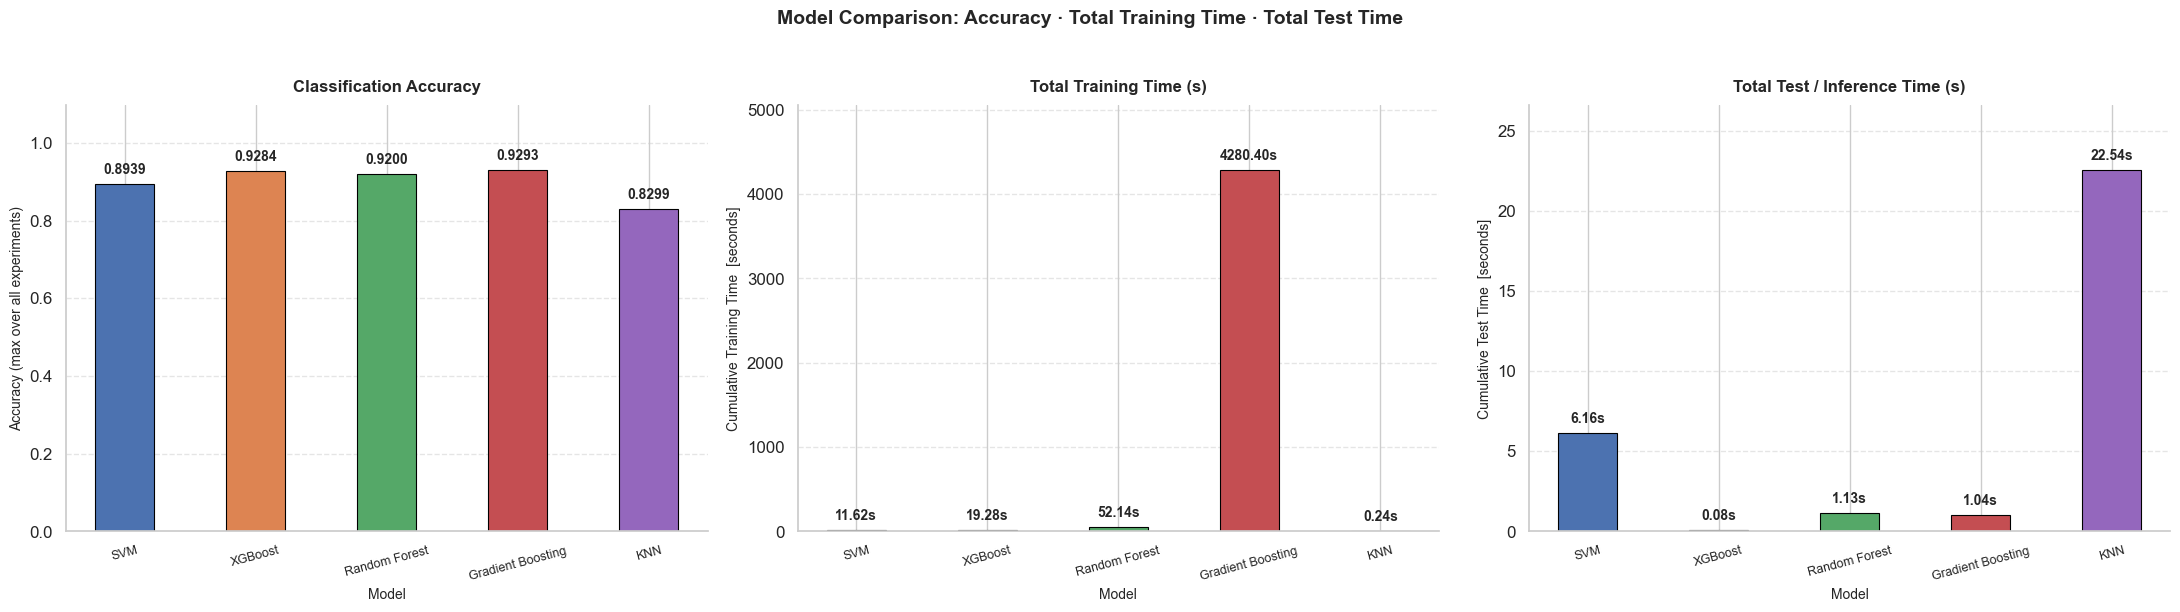

Figure saved as model_comparison_bars.png
FINAL COMPARISON TABLE — ALL 5 MODELS
Model                  Max Accuracy   Train Time (s)   Test Time (s)   # Exps
---------------------------------------------------------------------------
SVM                          0.8939            11.62          6.1646       34
XGBoost                      0.9284            19.28          0.0773       32
Random Forest                0.9200            52.14          1.1285       28
Gradient Boosting            0.9293          4280.40          1.0432       16
KNN                          0.8299             0.24         22.5359       21

  Most accurate     → Gradient Boosting
  Fastest training  → KNN
  Fastest inference → XGBoost


In [142]:
# ── Build per-model summary from results_log — ALL 5 models ──────────────────
res_df = pd.DataFrame(results_log)

MODEL_ORDER  = ['SVM', 'XGBoost', 'Random Forest', 'Gradient Boosting', 'KNN']
MODEL_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']

summary = (
    res_df.groupby('model')
    .agg(
        max_accuracy  = ('accuracy',     'max'),
        total_train_s = ('train_time_s', 'sum'),
        total_test_s  = ('test_time_s',  'sum'),
        n_experiments = ('accuracy',     'count')
    )
    .reindex(MODEL_ORDER)
    .reset_index()
)

print("=" * 65)
print("PER-MODEL AGGREGATE SUMMARY — ALL 5 MODELS")
print("=" * 65)
print(summary.to_string(index=False))
print()
print("Notes:")
print("  • Accuracy    = best (max) over all hyperparameter experiments")
print("  • Train Time  = sum of all .fit() calls (seconds)")
print("  • Test  Time  = sum of all .predict() calls (seconds)")

# ── Three bar graphs ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Model Comparison: Accuracy · Total Training Time · Total Test Time",
             fontsize=14, weight='bold', y=1.02)

metrics = [
    ('max_accuracy',  'Classification Accuracy',         'Accuracy (max over all experiments)', False),
    ('total_train_s', 'Total Training Time (s)',          'Cumulative Training Time  [seconds]',  True),
    ('total_test_s',  'Total Test / Inference Time (s)',  'Cumulative Test Time  [seconds]',       True),
]

for ax, (col, title, ylabel, show_time) in zip(axes, metrics):
    values = summary[col].values
    bars   = ax.bar(summary['model'], values,
                    color=MODEL_COLORS, width=0.45,
                    edgecolor='black', linewidth=0.8)

    for bar, val in zip(bars, values):
        label = f'{val:.2f}s' if show_time else f'{val:.4f}'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            label,
            ha='center', va='bottom',
            fontsize=10, weight='bold'
        )

    ax.set_title(title, fontsize=12, weight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylim(0, max(values) * 1.18)
    ax.tick_params(axis='x', labelrotation=15, labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as model_comparison_bars.png")

# ── Printed table recap ───────────────────────────────────────────────────────
print("=" * 75)
print("FINAL COMPARISON TABLE — ALL 5 MODELS")
print("=" * 75)
print(f"{'Model':<20} {'Max Accuracy':>14} {'Train Time (s)':>16} {'Test Time (s)':>15} {'# Exps':>8}")
print("-" * 75)
for _, row in summary.iterrows():
    print(f"{row['model']:<20} {row['max_accuracy']:>14.4f} "
          f"{row['total_train_s']:>16.2f} {row['total_test_s']:>15.4f} "
          f"{int(row['n_experiments']):>8}")
print("=" * 75)

fastest_train = summary.loc[summary['total_train_s'].idxmin(), 'model']
fastest_test  = summary.loc[summary['total_test_s'].idxmin(),  'model']
most_accurate = summary.loc[summary['max_accuracy'].idxmax(),  'model']

print(f"\n  Most accurate     → {most_accurate}")
print(f"  Fastest training  → {fastest_train}")
print(f"  Fastest inference → {fastest_test}")